# Plotting training results

This notebook serves as a visualization tool for the training results of the **FlowerLLM** training results.
It reads the metric from the training curves directly from Wandb and collect them in `pandas` data frames ready to be analyzed and plotted.

In [1]:
# Imports
from logging import INFO, ERROR
from typing import Any
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.style as mplstyle
import matplotlib.patches as mpatches
import wandb
import pandas as pd
import seaborn as sns
from matplotlib.ticker import MultipleLocator, MaxNLocator
import enum
from flwr.common import log

# Change font to respect submission requirements
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"
plt.rcParams["font.size"] = 14
plt.rcParams["font.weight"] = "bold"
# Colors and line styles
color_palette = sns.color_palette("colorblind")
line_styles = ["-", "--", ":", "-."]
LINE_WIDTH = 2.5
# Bolded axis labels
plt.rcParams["axes.labelweight"] = "bold"
mplstyle.use("fast")

In [7]:
import wandb
import time
def add_run_uuid(run_uuid: str, n_clients: int = 64, timeout: int = 10000) -> None:
    api = wandb.Api(timeout=timeout)
    for i in range(n_clients):
        try:
            actual_run_uuid = f"{run_uuid}_client_{i}"
            run = api.run(f"camlsys/pollen-llm/{actual_run_uuid}")
            run.config["run_uuid"] = run_uuid
            run.update()
        except Exception as e:
            print(e)
    try:
        actual_run_uuid = f"{run_uuid}_server"
        run = api.run(f"camlsys/pollen-llm/{actual_run_uuid}")
        run.config["run_uuid"] = run_uuid
        run.update()
    except Exception as e:
        print(e)
    try:
        actual_run_uuid = f"{run_uuid}"
        run = api.run(f"camlsys/pollen-llm/{actual_run_uuid}")
        run.config["run_uuid"] = run_uuid
        run.update()
    except Exception as e:
        print(e)

In [9]:
add_run_uuid("centralised-125M-20240510_095447_client_0")

Could not find run <Run camlsys/pollen-llm/centralised-125M-20240510_095447_client_0_client_1 (not found)>
Could not find run <Run camlsys/pollen-llm/centralised-125M-20240510_095447_client_0_client_2 (not found)>
Could not find run <Run camlsys/pollen-llm/centralised-125M-20240510_095447_client_0_client_3 (not found)>
Could not find run <Run camlsys/pollen-llm/centralised-125M-20240510_095447_client_0_client_4 (not found)>
Could not find run <Run camlsys/pollen-llm/centralised-125M-20240510_095447_client_0_client_5 (not found)>
Could not find run <Run camlsys/pollen-llm/centralised-125M-20240510_095447_client_0_client_6 (not found)>
Could not find run <Run camlsys/pollen-llm/centralised-125M-20240510_095447_client_0_client_7 (not found)>
Could not find run <Run camlsys/pollen-llm/centralised-125M-20240510_095447_client_0_client_8 (not found)>
Could not find run <Run camlsys/pollen-llm/centralised-125M-20240510_095447_client_0_client_9 (not found)>
Could not find run <Run camlsys/polle

In [2]:
class CentSuffix(str, enum.Enum):
    """Enum class for suffixes of centralized runs."""

    CENTRALIZED = "_centralised"
    CLIENT_0 = "_client_0"
    NONE = ""

In [3]:
class AxisLabels(str, enum.Enum):
    """Enum class for x- or y-axis labels."""

    FED_ROUND = "Federated Round"
    PPL = "Perplexity"
    CROSS_ENTROPY = "Cross Entropy"
    L2_NORM = "L2 Norm"
    ACT_MAX = "L2 Norm of Max Activation"

In [4]:
class PlottingCosmetics(str, enum.Enum):
    """Enum class for plotting cosmetics constants."""

    UPPER_RIGHT_POS = "upper right"
    UPPER_CENTER_POS = "upper center"
    CENTER_RIGHT_POS = "center right"

In [5]:
# Set the run_id to be retrieved
run_id_dict = {
    "fed-7B": [
        ("fed-7B-20240702_141659", 64, True, False),
    ],
    "cen-7B": [
        ("centralised-7B-20240704_131400_centralised", CentSuffix.NONE),
    ],
    "fed-1B-short": [
        ("fed-1B-20240322_221900-fix-nesto", 8, True, False),
        # ("fed-1B-20240509_061535", 8, True, False),
        ("fed-1B-20240510_074507", 8, True, False),
    ],
    "fed-1B-long": [
        ("fed-1B-20240314_232607", 8, True, False),
    ],
    "cen-1B": [
        ("centralised-1B-20240229_104204", CentSuffix.NONE),
    ],
    "fed-350M": [
        ("fed-350M-20240506_204125", 8, True, False),
        ("fed-350M-20240505_100605", 8, True, False),
    ],
    "cen-350M": [
        ("centralised-350M-20240305_191112", CentSuffix.NONE),
    ],
    "fed-160M": [],
    "cen-160M": [],
    "fed-125M": [
        ("fed-125M-20240502_203012-continue-3", 8, True, False),
        ("fed-125M-20240502_203012", 8, True, False),
    ],
    "cen-125M": [("centralised-125M-20240510_095447_client_0", CentSuffix.CLIENT_0)],
    "fed-75M": [("fed-75M-20240506_234900", 8, True, False)],
    "cen-75M": [("centralised-75M-20240508_212653", CentSuffix.CLIENT_0)],
    "fed-pile-75M-8": [
        ("pile-75M-final-20240605_133225-con", 8, True, False),
        ("pile-75M-final-20240605_133225", 8, True, False),
    ],
    "fed-pile-125M-8": [
        ("pile-125M-final-20240608_174142", 8, True, False),
    ],
    "cen-pile-75M-8": [("pile-75M-cent-20240607_105615", CentSuffix.CENTRALIZED)],
    "cen-pile-125M-8": [("pile-125M-cent-20240607_225637", CentSuffix.CENTRALIZED)],
    "fed-partial-75M-4_64": [("partial-75M-20240610_135450", 64, True, False)],
    "cen-partial-75M-4_64": [("centralised-75M-20240508_212653", CentSuffix.CLIENT_0)],
    "fed-partial-125M-4_64": [("partial-125M-20240611_011620", 64, True, False)],
    "cen-partial-125M-4_64": [
        ("centralised-125M-20240510_095447_client_0", CentSuffix.CLIENT_0)
    ],
    "fed-3B": [
        ("fed-3B-20240702_141112", 64, True, False),
    ],
    "cen-3B": [
        ("centralised-3B-20240324_191225", CentSuffix.NONE),
    ],
}

In [6]:
# Server metrics columns
server_metrics_columns = [
    # Train-specific metrics
    "LanguageCrossEntropy",
    "LanguagePerplexity",
    # Val-specific metrics
    "ValLanguageCrossEntropy",
    "ValLanguagePerplexity",
    # Wandb internals
    "_runtime",
    "_step",
    "_timestamp",
    # Client-side bookkeeping
    "client/eval_init_time",
    "client/eval_metrics_collection_time",
    "client/eval_time",
    "client/eval_trainer_closing_time",
    "client/fit_get_parameters_time",
    "client/fit_init_time",
    "client/fit_metrics_collection_time",
    "client/fit_time",
    "client/fit_trainer_closing_time",
    # Client-side metrics
    "client/l2_norm_pseudo_gradient",
    "client_state_acc",
    "distributed_loss",
    # Node-side bookkeeping
    "node_eval_time_s",
    "node_training_time_s",
    # Server-side bookkeeping
    "server/evaluate_round_time",
    "server/evaluate_time",
    "server/first_check_nm_time",
    "server/fit_round_time",
    "server/round_time",
    "server/second_check_nm_time",
    # Server-side computed norms
    "server/l2_norm_fedavg_result",
    "server/l2_norm_model",
    "server/l2_norm_momentum_vector",
    "server/l2_norm_pseudo_gradient",
    # Step
    "step",
    # Worker-side bookkeeping
    "worker/partial_aggregation_time",
]

In [7]:
# Client metrics columns
client_metrics_columns = [
    # Wandb internals
    "_runtime",
    "_step",
    "_timestamp",
    # Activation norms
    "activations/l2_norm/full_model_input",
    "activations/l2_norm/full_model_output",
    # CID
    "client_id",
    # Momentum, gradient and model norms
    "l2_norm/grad/global",
    "l2_norm/moment/global",
    "l2_norm/param/global",
    "l2_norm/update/global",
    # Train loss
    "loss/train/total",
    # LR
    "lr-DecoupledAdamW/group0",
    # Memory metrics
    "memory/alloc_retries",
    "memory/current_active_mem",
    "memory/current_allocated_mem",
    "memory/current_inactive_mem",
    "memory/current_reserved_mem",
    "memory/peak_active_mem",
    "memory/peak_allocated_mem",
    "memory/peak_inactive_mem",
    "memory/peak_reserved_mem",
    "metrics/train/LanguageCrossEntropy",
    "metrics/train/LanguagePerplexity",
    # Step
    "step",
    # Throughput metrics
    "throughput/batches_per_sec",
    "throughput/device/batches_per_sec",
    "throughput/device/flops_per_sec",
    "throughput/device/mfu",
    "throughput/device/samples_per_sec",
    "throughput/device/tokens_per_sec",
    "throughput/flops_per_sec",
    "throughput/samples_per_sec",
    "throughput/tokens_per_sec",
    # Time metrics
    "time/batch",
    "time/batch_in_epoch",
    "time/epoch",
    "time/remaining_estimate",
    "time/sample",
    "time/sample_in_epoch",
    "time/token",
    "time/token_in_epoch",
    "time/total",
    "time/train",
    "time/val",
    # Microbatch size
    "trainer/device_train_microbatch_size",
]

In [8]:
x_lim: tuple[float, float] | None = None
perplexity_y_lim: dict[str, float] | None = {"top": 225, "bottom": 0}
norm_y_lim: dict[str, float] | None = {"bottom": 300, "top": 900}
momentum_y_lim: dict[str, float] | None = {"bottom": 300, "top": 900}
grad_y_lim: dict[str, float] | None = {"bottom": 0, "top": 125}
grad_client_y_lim: dict[str, float] | None = {"bottom": 0, "top": 1.6}
lr_y_lim: dict[str, float] | None = None
act_out_y_lim: dict[str, float] | None = None
act_out_y_lim: dict[str, float] | None = {"bottom": 0, "top": 1.3 * 1e7}
perplexity_legend_kwargs: dict[str, Any] | None = None
l2_gradient_legend_kwargs: dict[str, Any] | None = None

In [9]:
def download_metrics(
    run_id: str, n_clients: int, drop_layers: bool = True, use_server_name: bool = False
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Download all the metrics from given run_id using Wandb API."""
    # Initialize the wandb API
    api = wandb.Api(timeout=100)
    # Get the run object
    server_run = (
        api.run(f"camlsys/pollen-llm/{run_id}_server")
        if use_server_name
        else api.run(f"camlsys/pollen-llm/{run_id}")
    )
    # Get the metrics
    server_metrics = server_run.scan_history()
    # Convert the metrics to a pandas data frame
    server_metrics_df = pd.DataFrame(server_metrics)
    # Drop the layers columns if needed
    if drop_layers:
        layer_columns = [col for col in server_metrics_df.columns if "layer" in col]
        server_metrics_df = server_metrics_df.drop(columns=layer_columns)
    # Add the `step` column based on the index
    server_metrics_df["step"] = server_metrics_df.index
    # Get clients metrics
    clients_metrics_df_list: list[pd.DataFrame] = []

    for i in range(n_clients):
        try:
            # Get the run object

            client_run = (
                api.run(f"camlsys/pollen-llm/{run_id}_client_{i}")
                if (
                    run_id
                    not in {
                        "pile-75M-final-20240605_133225",
                        "partial-75M-20240605_133326",
                    }
                )
                else api.run(f"camlsys/pollen-llm/{run_id}client_{i}")
            )
            # Get the metrics
            client_metrics = client_run.scan_history()
            # Convert the metrics to a pandas data frame
            client_metrics_df = pd.DataFrame(client_metrics)
            # Drop the layers columns if needed
            if drop_layers:
                layer_columns = [
                    col for col in client_metrics_df.columns if "layer" in col
                ]
                client_metrics_df = client_metrics_df.drop(columns=layer_columns)
            # Add the `step` column based on the index
            client_metrics_df["step"] = client_metrics_df._step
            # Add the `client_id` column based on the current client_id
            client_metrics_df["client_id"] = i
            # Append the client metrics to the list
            clients_metrics_df_list.append(client_metrics_df)
        except Exception as e:
            log(
                ERROR,
                f"Client {i} not found for run {run_id}",
                stack_info=True,
                exc_info=e,
            )
    # Concatenate the clients metrics
    clients_metrics_df = pd.concat(clients_metrics_df_list)
    # Return the metrics data frame
    return server_metrics_df, clients_metrics_df

In [10]:
def download_metrics_centralized(
    run_id: str,
    suffix: str,
) -> pd.DataFrame:
    """Download all the metrics from given run_id using Wandb API."""
    # Initialize the wandb API
    api = wandb.Api()
    # Get the run object
    cent_run = api.run(f"camlsys/pollen-llm/{run_id}{suffix}")
    # Get the metrics
    cent_metrics = cent_run.scan_history()
    # Convert the metrics to a pandas data frame
    cent_metrics_df = pd.DataFrame(cent_metrics)

    # Add the `step` column based on the index
    cent_metrics_df["step"] = cent_metrics_df.index

    # Return the metrics data frame
    return cent_metrics_df

In [11]:
def plot_single_federated_run_ppl(
    server_data_frame: pd.DataFrame,
    clients_data_frame: pd.DataFrame,
    centralized_data_frame: pd.DataFrame | None = None,
    file_name: str | None = None,
    x_lim: tuple[float, float] | None = None,
    y_lim: dict[str, float] | None = None,
    legend_kwargs: dict[str, Any] | None = None,
) -> None:
    """Plot the metrics from a single federated run."""
    # Sort `server_data_frame` by `_step`
    tmp_server_data_frame = server_data_frame.sort_values(by="_step")
    # Reset the index of `server_data_frame`
    tmp_server_data_frame = tmp_server_data_frame.reset_index(drop=True)
    # Plot nicely using matplotlib `ValLanguagePerplexity` versus `_step` from server
    # data frame dropping NaN values
    plt.figure(figsize=(10, 5))

    # Sort `clients_data_frame` by `_step`
    tmp_clients_data_frame = clients_data_frame.sort_values(by="_step")
    # Reset the index of `clients_data_frame`
    tmp_clients_data_frame = tmp_clients_data_frame.reset_index(drop=True)
    # Keep only steps that are multiples of 10
    tmp_clients_data_frame = tmp_clients_data_frame[
        tmp_clients_data_frame["_step"] % 10 == 0
    ]
    # Divide the number the column `_step` by 500
    tmp_clients_data_frame["this_plot_step"] = tmp_clients_data_frame["_step"] / 500
    # Remove data points past the x_lim

    if x_lim:
        tmp_clients_data_frame = tmp_clients_data_frame[
            tmp_clients_data_frame["this_plot_step"] <= x_lim[1]
        ]
        tmp_server_data_frame = tmp_server_data_frame[
            tmp_server_data_frame["_step"] <= x_lim[1]
        ]

    sns.lineplot(
        data=tmp_server_data_frame,
        x="_step",
        y="ValLanguagePerplexity",
        label="Global Model Validation",
        alpha=0.5,
        color=color_palette[0],
        linestyle=line_styles[0],
        linewidth=LINE_WIDTH,  # Increase line width
    )

    sns.lineplot(
        data=tmp_clients_data_frame,
        x="this_plot_step",
        y="metrics/train/LanguagePerplexity",
        label="Client Model Train",
        alpha=0.5,
        color=color_palette[1],
        linestyle=line_styles[1],
        linewidth=LINE_WIDTH,  # Increase line width
    )
    if centralized_data_frame is not None:
        # Sort `centralized_data_frame` by `_step`
        tmp_centralized_data_frame = centralized_data_frame.sort_values(by="_step")
        tmp_centralized_data_frame = tmp_centralized_data_frame[
            tmp_centralized_data_frame["_step"] % 10 == 0
        ]
        tmp_centralized_data_frame["this_plot_step"] = (
            tmp_centralized_data_frame["_step"] / 500
        )
        # Reset the index of `centralized_data_frame`
        tmp_centralized_data_frame = tmp_centralized_data_frame.reset_index(drop=True)
        if x_lim:
            tmp_centralized_data_frame = tmp_centralized_data_frame[
                tmp_centralized_data_frame["this_plot_step"] <= x_lim[1]
            ]
        sns.lineplot(
            data=tmp_centralized_data_frame,
            x="this_plot_step",
            y="metrics/eval/LanguagePerplexity",
            label="Centralized Model Validation",
            alpha=0.5,
            # color=color_palette[2],
            color="black",
            # linestyle=line_styles[2],
            linestyle="--",
            linewidth=LINE_WIDTH,  # Increase line width
        )
        sns.lineplot(
            data=tmp_centralized_data_frame,
            x="this_plot_step",
            y="metrics/train/LanguagePerplexity",
            label="Centralized Model Train",
            alpha=0.5,
            # color=color_palette[3],
            color="black",
            # linestyle=line_styles[2],
            linestyle="-",
            linewidth=LINE_WIDTH,  # Increase line width
        )
    # Set the maximum y-axis limit to 500
    if x_lim:
        plt.xlim([x_lim[0] - 0.5, x_lim[1] + 0.5])
    if y_lim:
        plt.ylim(**y_lim)
    # Reconcile ticks and limits
    _y_ticks = plt.yticks()[0]
    delta = _y_ticks[-1] - _y_ticks[-2]
    plt.ylim(_y_ticks[0], _y_ticks[-1] + (1 / 6) * delta)
    plt.yticks(_y_ticks)

    plt.gca().yaxis.set_minor_locator(MultipleLocator(5))

    # Force x-ticks to be integers
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.grid(which="major")
    plt.minorticks_on()  # Turn on the minor ticks
    # Set x and y labels
    plt.xlabel(AxisLabels.FED_ROUND.value)
    plt.ylabel(AxisLabels.PPL.value)
    # Apply legend kwargs if any
    if legend_kwargs:
        plt.legend(**legend_kwargs)
    # Save the figure
    if file_name:
        plt.savefig(file_name, format="pdf", dpi=800, bbox_inches="tight")
    # Show the figure
    plt.show()

In [12]:
def plot_single_federated_run_l2_model(
    server_data_frame: pd.DataFrame,
    clients_data_frame: pd.DataFrame,
    file_name: str | None = None,
    x_lim: tuple[float, float] | None = None,
    y_lim: dict[str, float] | None = None,
) -> None:
    """Plot the metrics from a single federated run."""
    # Sort `server_data_frame` by `_step`
    tmp_server_data_frame = server_data_frame.sort_values(by="_step")
    # Reset the index of `server_data_frame`
    tmp_server_data_frame = tmp_server_data_frame.reset_index(drop=True)
    # Plot nicely using matplotlib `ValLanguagePerplexity` versus `_step` from server
    # data frame dropping NaN values

    # Sort `clients_data_frame` by `_step`
    tmp_clients_data_frame = clients_data_frame.sort_values(by="_step")
    # Reset the index of `clients_data_frame`
    tmp_clients_data_frame = tmp_clients_data_frame.reset_index(drop=True)
    # Keep only steps that are multiples of 10
    tmp_clients_data_frame = tmp_clients_data_frame[
        tmp_clients_data_frame["_step"] % 10 == 0
    ]
    # Divide the number the column `_step` by 500
    tmp_clients_data_frame["this_plot_step"] = tmp_clients_data_frame["_step"] / 500

    if x_lim:
        tmp_clients_data_frame = tmp_clients_data_frame[
            tmp_clients_data_frame["this_plot_step"] <= x_lim[1]
        ]
        tmp_server_data_frame = tmp_server_data_frame[
            tmp_server_data_frame["_step"] <= x_lim[1]
        ]

    plt.figure(figsize=(10, 5))
    sns.lineplot(
        data=tmp_server_data_frame,
        x="_step",
        y="server/l2_norm_model",
        label="Global Model - FedMom",
        alpha=0.5,
        color=color_palette[0],
        linestyle=line_styles[0],
        linewidth=LINE_WIDTH,  # Increase line width
    )
    sns.lineplot(
        data=tmp_server_data_frame,
        x="_step",
        y="server/l2_norm_fedavg_result",
        label="Global Model - FedAvg",
        alpha=0.5,
        color=color_palette[1],
        linestyle=line_styles[0],
        linewidth=LINE_WIDTH,  # Increase line width
    )

    sns.lineplot(
        data=tmp_clients_data_frame,
        x="this_plot_step",
        y="l2_norm/param/global",
        label="Client Model",
        alpha=0.5,
        color=color_palette[3],
        linestyle=line_styles[1],
        linewidth=LINE_WIDTH,  # Increase line width
    )
    if x_lim:
        plt.xlim([x_lim[0] - 0.5, x_lim[1] + 0.5])
    if y_lim:
        plt.ylim(**y_lim)  # Put a 1/6 of tick gap additional space on top
    # Reconcile ticks and limits
    _y_ticks = plt.yticks()[0]
    delta = _y_ticks[-1] - _y_ticks[-2]
    plt.ylim(_y_ticks[0], _y_ticks[-1] + (1 / 6) * delta)
    plt.yticks(_y_ticks)
    # Add minor ticks
    plt.gca().yaxis.set_minor_locator(MultipleLocator(5))

    # Force x-ticks to be integers
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.grid()
    plt.minorticks_on()  # Turn on the minor ticks
    # Set x and y labels
    plt.xlabel(AxisLabels.FED_ROUND.value)
    plt.ylabel("L2 Norm")
    # Save the figure
    if file_name:
        plt.savefig(file_name, format="pdf", dpi=800, bbox_inches="tight")
    # Show the figure
    plt.show()

In [13]:
def plot_single_federated_run_l2_gradient(
    server_data_frame: pd.DataFrame,
    clients_data_frame: pd.DataFrame,
    file_name: str | None = None,
    x_lim: tuple[float, float] | None = None,
    y_lim: dict[str, float] | None = None,
    client_y_lim: dict[str, float] | None = None,
    legend_kwargs: dict[str, Any] | None = None,
) -> None:
    """Plot the metrics from a single federated run."""
    # Sort `server_data_frame` by `_step`
    tmp_server_data_frame = server_data_frame.sort_values(by="_step")
    # Reset the index of `server_data_frame`
    tmp_server_data_frame = tmp_server_data_frame.reset_index(drop=True)
    # Plot nicely using matplotlib `ValLanguagePerplexity` versus `_step` from server
    # data frame dropping NaN values
    # Sort `clients_data_frame` by `_step`
    tmp_clients_data_frame = clients_data_frame.sort_values(by="_step")
    # Reset the index of `clients_data_frame`
    tmp_clients_data_frame = tmp_clients_data_frame.reset_index(drop=True)
    # Keep only steps that are multiples of 10
    tmp_clients_data_frame = tmp_clients_data_frame[
        tmp_clients_data_frame["_step"] % 10 == 0
    ]
    # Divide the number the column `_step` by 500
    tmp_clients_data_frame["this_plot_step"] = tmp_clients_data_frame["_step"] / 500
    if x_lim:
        tmp_clients_data_frame = tmp_clients_data_frame[
            tmp_clients_data_frame["this_plot_step"] <= x_lim[1]
        ]
        tmp_server_data_frame = tmp_server_data_frame[
            tmp_server_data_frame["_step"] <= x_lim[1]
        ]

    plt.figure(figsize=(10, 5))
    patches = []
    sns.lineplot(
        data=tmp_server_data_frame,
        x="_step",
        y="server/l2_norm_pseudo_gradient",
        label="FedAvg Pseudo-Gradient",
        alpha=0.5,
        color=color_palette[0],
        linestyle=line_styles[0],
        linewidth=LINE_WIDTH,  # Increase line width
    )
    patches.append(
        mpatches.Patch(
            color=color_palette[0],
            linestyle=line_styles[0],
            label="FedAvg Pseudo-Gradient",
        )
    )

    # Add a new y-axis for the next plot
    plt.ylabel("FedAvg L2 Norm")
    plt.xlabel(AxisLabels.FED_ROUND.value)

    if x_lim:
        plt.xlim([x_lim[0] - 0.5, x_lim[1] + 0.5])
    if y_lim:
        plt.ylim(**y_lim)

    plt.grid()
    plt.legend().remove()
    # plt.gca().yaxis.set_minor_locator(MultipleLocator(25))

    # Create evenly spaced values over each range
    num_ticks = 6  # for example, if you want 5 ticks on each axis
    y1_ticks = np.linspace(plt.ylim()[0], plt.ylim()[1], num_ticks)

    # Add minor ticks
    plt.gca().yaxis.set_minor_locator(MultipleLocator(5))
    # plt.grid(which="major")
    plt.minorticks_on()  # Turn on the minor ticks
    # Set the ticks for each axis
    plt.gca().set_yticks(y1_ticks)
    # Reconcile ticks and limits
    delta = y1_ticks[-1] - y1_ticks[-2]
    plt.ylim(y1_ticks[0], y1_ticks[-1] + (1 / 6) * delta)
    ax2 = plt.twinx()
    if client_y_lim:
        ax2.set_ylim(**client_y_lim)  # type: ignore[reportArgumentType]
    y2_ticks = np.linspace(plt.ylim()[0], plt.ylim()[1], num_ticks)
    y2_ticks_labels = np.round(y2_ticks, decimals=1)  # round to nearest decimal
    ax2.set_yticks(y2_ticks)
    ax2.set_yticklabels(y2_ticks_labels)
    # Reconcile ticks and limits
    delta = y2_ticks[-1] - y2_ticks[-2]
    ax2.set_ylim(y2_ticks[0], y2_ticks[-1] + (1 / 6) * delta)
    sns.lineplot(
        data=tmp_clients_data_frame,
        x="this_plot_step",
        y="l2_norm/grad/global",
        label="Client Computed Step-Gradient",
        alpha=0.5,
        ax=ax2,
        color=color_palette[1],
        linestyle=line_styles[1],
        linewidth=LINE_WIDTH,  # Increase line width
    )
    patches.append(
        mpatches.Patch(
            color=color_palette[1],
            linestyle=line_styles[1],
            label="Client Computed Step-Gradient",
        )
    )
    sns.lineplot(
        data=tmp_clients_data_frame,
        x="this_plot_step",
        y="l2_norm/update/global",
        label="Client Applied Step-Gradient",
        alpha=0.5,
        ax=ax2,
        color=color_palette[2],
        linestyle=line_styles[1],
        linewidth=LINE_WIDTH,  # Increase line width
    )
    patches.append(
        mpatches.Patch(
            color=color_palette[2],
            linestyle=line_styles[1],
            label="Client Applied Step-Gradient",
        )
    )
    # Set x and y labels
    plt.xlabel(AxisLabels.FED_ROUND.value)
    plt.ylabel("Client L2 Norm")
    # Add minor ticks
    plt.gca().yaxis.set_minor_locator(MultipleLocator(5))

    # Force x-ticks to be integers
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.grid()
    plt.minorticks_on()  # Turn on the minor ticks
    # Add the legend manually
    if legend_kwargs:
        plt.legend(**legend_kwargs, handles=patches)
    else:
        plt.legend(handles=patches)
    # Save the figure
    if file_name:
        plt.savefig(file_name, format="pdf", dpi=800, bbox_inches="tight")
    # Show the figure
    plt.show()

In [14]:
def plot_single_federated_run_l2_global_momentum(
    server_data_frame: pd.DataFrame,
    file_name: str | None = None,
    x_lim: tuple[float, float] | None = None,
    y_lim: dict[str, float] | None = None,
    legend_loc: str = "right",
) -> None:
    """Plot the metrics from a single federated run."""
    # Sort `server_data_frame` by `_step`
    tmp_server_data_frame = server_data_frame.sort_values(by="_step")
    # Reset the index of `server_data_frame`
    tmp_server_data_frame = tmp_server_data_frame.reset_index(drop=True)
    # Plot nicely using matplotlib `ValLanguagePerplexity` versus `_step` from server data
    # frame dropping NaN values
    if x_lim:
        tmp_server_data_frame = tmp_server_data_frame[
            tmp_server_data_frame["_step"] <= x_lim[1]
        ]
    plt.figure(figsize=(10, 5))
    patches = []
    sns.lineplot(
        data=tmp_server_data_frame,
        x="_step",
        y="server/l2_norm_momentum_vector",
        label="Global Momentum",
        alpha=0.5,
        color=color_palette[0],
        linestyle=line_styles[0],
        linewidth=LINE_WIDTH,  # Increase line width
    )
    patches.append(
        mpatches.Patch(
            color=color_palette[0],
            linestyle=line_styles[0],
            label="Global Momentum",
        )
    )
    sns.lineplot(
        data=tmp_server_data_frame,
        x="_step",
        y="server/l2_norm_model",
        label="Global Model",
        alpha=0.5,
        color=color_palette[1],
        linestyle=line_styles[0],
        linewidth=LINE_WIDTH,  # Increase line width
    )
    patches.append(
        mpatches.Patch(
            color=color_palette[1],
            linestyle=line_styles[0],
            label="Global Model",
        )
    )
    if x_lim:
        plt.xlim([x_lim[0] - 0.5, x_lim[1] + 0.5])
    if y_lim:
        plt.ylim(**y_lim)
    # Reconcile ticks and limits
    _y_ticks = plt.yticks()[0]
    delta = _y_ticks[-1] - _y_ticks[-2]
    plt.ylim(_y_ticks[0], _y_ticks[-1] + (1 / 6) * delta)
    plt.yticks(_y_ticks)
    # Set x and y labels
    plt.xlabel(AxisLabels.FED_ROUND.value)
    plt.ylabel("L2 Norm")
    # Add minor ticks
    plt.gca().yaxis.set_minor_locator(MultipleLocator(5))

    # Force x-ticks to be integers
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.grid()
    plt.minorticks_on()  # Turn on the minor ticks
    # Add the legend manually
    plt.legend(loc=legend_loc, handles=patches)
    # Save the figure
    if file_name:
        plt.savefig(file_name, format="pdf", dpi=800, bbox_inches="tight")
    # Show the figure
    plt.show()

In [15]:
def plot_single_federated_run_output_activation(
    clients_data_frame: pd.DataFrame,
    centralized_data_frame: pd.DataFrame | None = None,
    file_name: str | None = None,
    x_lim: tuple[float, float] | None = None,
    y_lim: dict[str, float] | None = None,
) -> None:
    """Plot the metrics from a single federated run."""
    # Plot nicely using matplotlib `ValLanguagePerplexity` versus `_step` from server
    # data frame dropping NaN values
    plt.figure(figsize=(10, 5))
    # Sort `clients_data_frame` by `_step`
    tmp_clients_data_frame = clients_data_frame.sort_values(by="_step")
    # Reset the index of `clients_data_frame`
    tmp_clients_data_frame = tmp_clients_data_frame.reset_index(drop=True)
    # Keep only steps that are multiples of 10
    tmp_clients_data_frame = tmp_clients_data_frame[
        tmp_clients_data_frame["_step"] % 10 == 0
    ]
    # Divide the number the column `_step` by 500
    tmp_clients_data_frame["this_plot_step"] = tmp_clients_data_frame["_step"] / 500

    if x_lim:
        tmp_clients_data_frame = tmp_clients_data_frame[
            tmp_clients_data_frame["this_plot_step"] <= x_lim[1]
        ]

    # Add a new y-axis for the next plot
    sns.lineplot(
        data=tmp_clients_data_frame,
        x="this_plot_step",
        y="activations/l2_norm/full_model_output",
        alpha=0.5,
        color=color_palette[3],
        label="Client Output Activations",
        linestyle=line_styles[1],
        linewidth=LINE_WIDTH,  # Increase line width
    )
    if centralized_data_frame is not None:
        tmp_centralized_data_frame = centralized_data_frame.sort_values(by="_step")
        tmp_centralized_data_frame = tmp_centralized_data_frame[
            tmp_centralized_data_frame["_step"] % 10 == 0
        ]
        tmp_centralized_data_frame["this_plot_step"] = (
            tmp_centralized_data_frame["_step"] / 500
        )
        tmp_centralized_data_frame = tmp_centralized_data_frame.reset_index(drop=True)

        if x_lim:
            tmp_centralized_data_frame = tmp_centralized_data_frame[
                tmp_centralized_data_frame["this_plot_step"] <= x_lim[1]
            ]

        sns.lineplot(
            data=tmp_centralized_data_frame,
            x="this_plot_step",
            y="activations/l2_norm/full_model_output",
            alpha=0.5,
            color=color_palette[4],
            label="Centralized Output Activations",
            linestyle=line_styles[0],
            linewidth=LINE_WIDTH,  # Increase line width
        )

    # Set x and y labels
    plt.xlabel(AxisLabels.FED_ROUND.value)
    plt.ylabel("L2 Norm")
    if x_lim:
        plt.xlim([x_lim[0] - 0.5, x_lim[1] + 0.5])
    if y_lim:
        plt.ylim(**y_lim)
    # Reconcile ticks and limits
    _y_ticks = plt.yticks()[0]
    delta = _y_ticks[-1] - _y_ticks[-2]
    plt.ylim(_y_ticks[0], _y_ticks[-1] + (1 / 6) * delta)
    plt.yticks(_y_ticks)
    # Add minor ticks
    plt.gca().yaxis.set_minor_locator(MultipleLocator(5))

    # Force x-ticks to be integers
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.grid()
    plt.minorticks_on()  # Turn on the minor ticks

    # plt.legend()
    # plt.grid()
    # Save the figure
    if file_name:
        plt.savefig(file_name, format="pdf", dpi=800, bbox_inches="tight")
    # Show the figure
    plt.show()

In [16]:
def plot_single_federated_run_lr(
    clients_data_frame: pd.DataFrame,
    file_name: str | None = None,
    x_lim: tuple[float, float] | None = None,
    y_lim: dict[str, float] | None = None,
) -> None:
    """Plot the metrics from a single federated run."""
    # Plot nicely using matplotlib `ValLanguagePerplexity` versus `_step` from server data
    # frame dropping NaN values
    plt.figure(figsize=(10, 5))
    # Sort `clients_data_frame` by `_step`
    tmp_clients_data_frame = clients_data_frame.sort_values(by="_step")
    # Reset the index of `clients_data_frame`
    tmp_clients_data_frame = tmp_clients_data_frame.reset_index(drop=True)
    # Keep only steps that are multiples of 10
    tmp_clients_data_frame = tmp_clients_data_frame[
        tmp_clients_data_frame["_step"] % 10 == 0
    ]
    # Divide the number the column `_step` by 500
    tmp_clients_data_frame["this_plot_step"] = tmp_clients_data_frame["_step"] / 500
    if x_lim:
        tmp_clients_data_frame = tmp_clients_data_frame[
            tmp_clients_data_frame["this_plot_step"] <= x_lim[1]
        ]
    # Add a new y-axis for the next plot
    sns.lineplot(
        data=tmp_clients_data_frame,
        x="this_plot_step",
        y="lr-DecoupledAdamW/group0",
        alpha=0.5,
        color=color_palette[2],
        linestyle=line_styles[1],
        linewidth=LINE_WIDTH,  # Increase line width
    )
    if x_lim:
        plt.xlim([x_lim[0] - 0.5, x_lim[1] + 0.5])
    if y_lim:
        plt.ylim(**y_lim)

    # Force x-ticks to be integers
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    # Set x and y labels
    plt.xlabel(AxisLabels.FED_ROUND.value)
    plt.ylabel("Client Learning Rate")
    plt.grid()
    # Save the figure
    if file_name:
        plt.savefig(file_name, format="pdf", dpi=800, bbox_inches="tight")
    # Show the figure
    plt.show()

In [17]:
def plot_single_federated_run_input_activation(
    clients_data_frame: pd.DataFrame,
    centralized_data_frame: pd.DataFrame | None = None,
    file_name: str | None = None,
    x_lim: tuple[float, float] | None = None,
) -> None:
    """Plot the metrics from a single federated run."""
    # Plot nicely using matplotlib `ValLanguagePerplexity` versus `_step` from server
    # data frame dropping NaN values
    plt.figure(figsize=(10, 5))
    # Sort `clients_data_frame` by `_step`
    tmp_clients_data_frame = clients_data_frame.sort_values(by="_step")
    # Reset the index of `clients_data_frame`
    tmp_clients_data_frame = tmp_clients_data_frame.reset_index(drop=True)
    # Keep only steps that are multiples of 10
    tmp_clients_data_frame = tmp_clients_data_frame[
        tmp_clients_data_frame["_step"] % 10 == 0
    ]
    # Divide the number the column `_step` by 500
    tmp_clients_data_frame["this_plot_step"] = tmp_clients_data_frame["_step"] / 500
    if x_lim:
        tmp_clients_data_frame = tmp_clients_data_frame[
            tmp_clients_data_frame["this_plot_step"] <= x_lim[1]
        ]

    # Add a new y-axis for the next plot
    sns.lineplot(
        data=tmp_clients_data_frame,
        x="this_plot_step",
        y="activations/l2_norm/full_model_input",
        alpha=0.5,
        color=color_palette[3],
        label="Client Input Activations",
        linestyle=line_styles[1],
        linewidth=LINE_WIDTH,  # Increase line width
    )
    if centralized_data_frame is not None:
        tmp_centralized_data_frame = centralized_data_frame.sort_values(by="_step")
        tmp_centralized_data_frame = tmp_centralized_data_frame[
            tmp_centralized_data_frame["_step"] % 10 == 0
        ]
        tmp_centralized_data_frame["this_plot_step"] = (
            tmp_centralized_data_frame["_step"] / 500
        )
        tmp_centralized_data_frame = tmp_centralized_data_frame.reset_index(drop=True)

        if x_lim:
            tmp_centralized_data_frame = tmp_centralized_data_frame[
                tmp_centralized_data_frame["this_plot_step"] <= x_lim[1]
            ]

        sns.lineplot(
            data=tmp_centralized_data_frame,
            x="this_plot_step",
            y="activations/l2_norm/full_model_input",
            alpha=0.5,
            color=color_palette[4],
            label="Centralized Input Activations",
            linestyle=line_styles[0],
            linewidth=LINE_WIDTH,  # Increase line width
        )
    if x_lim:
        plt.xlim([x_lim[0] - 0.5, x_lim[1] + 0.5])

    # Force x-ticks to be integers
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    # Set x and y labels
    plt.xlabel(AxisLabels.FED_ROUND.value)
    plt.ylabel("L2 Norm")
    plt.grid()
    # plt.legend()
    # Save the figure
    if file_name:
        plt.savefig(file_name, format="pdf", dpi=800, bbox_inches="tight")
    # Show the figure
    plt.show()

In [18]:
def plot_block_wise_heatmap(
    server_data_frame: pd.DataFrame,
    layer_wise_metric: str = "/l2_norm_pseudo_gradient",
    block_size: int = 12,
    cmap: str = "coolwarm",
    normalize: bool = False,
) -> None:
    """Plot a heatmap with the round as the x-axis and the layer index as the y-axis.

    Layers are processed in blocks of block_size starting from the end
    """
    layer_df = server_data_frame.filter(like=layer_wise_metric)
    stripped_columns = layer_df.rename(
        columns=lambda x: x.replace(layer_wise_metric, "")
    )
    stripped_columns = stripped_columns.rename(
        columns=lambda x: x.replace("server/layer/", "")
    )
    # stripped_columns = stripped_columns.drop(columns=["server", "client"])
    stripped_columns = stripped_columns.drop(columns=["server"])
    log(INFO, stripped_columns.columns)
    new_columns = {
        col: pd.to_numeric(col, errors="coerce") for col in stripped_columns.columns
    }
    numeric_columns = stripped_columns.rename(columns=new_columns)
    sorted_columns = numeric_columns.sort_index(axis=1, ascending=True)
    log(INFO, sorted_columns)
    transposed_dataframe = sorted_columns.T

    if normalize:
        transposed_dataframe = transposed_dataframe.apply(
            lambda x: (x - x.min()) / (x.max() - x.min()), axis=1
        )

    for i in range(len(transposed_dataframe) - 1, -1, -block_size):
        # Select the columns for this heatmap
        start = max(0, i - block_size + 1)
        end = i + 1
        subset = transposed_dataframe.iloc[start:end]

        # Create the heatmap
        sns.heatmap(subset, cmap=cmap)
        plt.title(f"Heatmap for layers {start} to {end}")
        plt.xlabel("Round")
        plt.ylabel("Layer Index")
        plt.savefig(f"norm_heatmap_{i}")
        plt.close()

In [19]:
def run_all_plotting(
    _server_data_frame: pd.DataFrame | None,
    _clients_data_frame: pd.DataFrame | None,
    _centralized_df: pd.DataFrame | None,
    _file_name: str,
    _x_lim: tuple[float, float] | None,
    _perplexity_y_lim: dict[str, float] | None,
    _momentum_y_lim: dict[str, float] | None,
    _grad_y_lim: dict[str, float] | None,
    _grad_client_y_lim: dict[str, float] | None,
    _norm_y_lim: dict[str, float] | None,
    _act_out_y_lim: dict[str, float] | None,
    _perplexity_legend_kwargs: dict[str, Any] | None,
    _l2_gradient_legend_kwargs: dict[str, Any] | None,
) -> None:
    if _server_data_frame is not None or _clients_data_frame is not None:
        assert _server_data_frame is not None and _clients_data_frame is not None
        plot_single_federated_run_ppl(
            _server_data_frame,
            _clients_data_frame,
            _centralized_df,
            file_name=f"perplexity_{_file_name}",
            x_lim=_x_lim,
            y_lim=_perplexity_y_lim,
            legend_kwargs=_perplexity_legend_kwargs,
        )

        try:
            plot_single_federated_run_l2_model(
                _server_data_frame,
                _clients_data_frame,
                file_name=f"l2_{_file_name}",
                x_lim=_x_lim,
                y_lim=_norm_y_lim,
            )
        except Exception as e:
            log(ERROR, "No L2 model norm to plot", stack_info=True, exc_info=e)

        try:
            plot_single_federated_run_l2_global_momentum(
                _server_data_frame,
                file_name=f"nesterov_{_file_name}",
                x_lim=_x_lim,
                y_lim=_momentum_y_lim,
                legend_loc=PlottingCosmetics.UPPER_RIGHT_POS.value,
            )
        except Exception as e:
            log(ERROR, "No L2 momentum norm to plot", stack_info=True, exc_info=e)

        try:
            plot_single_federated_run_l2_gradient(
                _server_data_frame,
                _clients_data_frame,
                file_name=f"cdf_{_file_name}",
                x_lim=_x_lim,
                y_lim=_grad_y_lim,
                client_y_lim=_grad_client_y_lim,
                legend_kwargs=_l2_gradient_legend_kwargs,
            )
        except Exception as e:
            log(ERROR, "No L2 gradient norm to plot", stack_info=True, exc_info=e)

    if _clients_data_frame is not None:
        assert _clients_data_frame is not None
        try:
            plot_single_federated_run_output_activation(
                _clients_data_frame,
                centralized_data_frame=_centralized_df,
                file_name=f"act_out_{_file_name}",
                x_lim=_x_lim,
                y_lim=_act_out_y_lim,
            )
        except Exception as e:
            log(ERROR, "No output activation norm to plot", stack_info=True, exc_info=e)

    # plot_single_federated_run_lr(
    #     _clients_data_frame, file_name=f"lr_{_file_name}", x_lim=_x_lim, y_lim=lr_y_lim
    # )

    # plot_single_federated_run_input_activation(
    #     _clients_data_frame,
    #     centralized_data_frame=_centralized_df,
    #     file_name=f"act_input_{_file_name}",
    #     x_lim=_x_lim,
    # )

    # plot_block_wise_heatmap(_server_data_frame, layer_wise_metric="/l2_norm_model")

    # plot_block_wise_heatmap(
    #     _server_data_frame, layer_wise_metric="/l2_norm_model", normalize=True
    # )

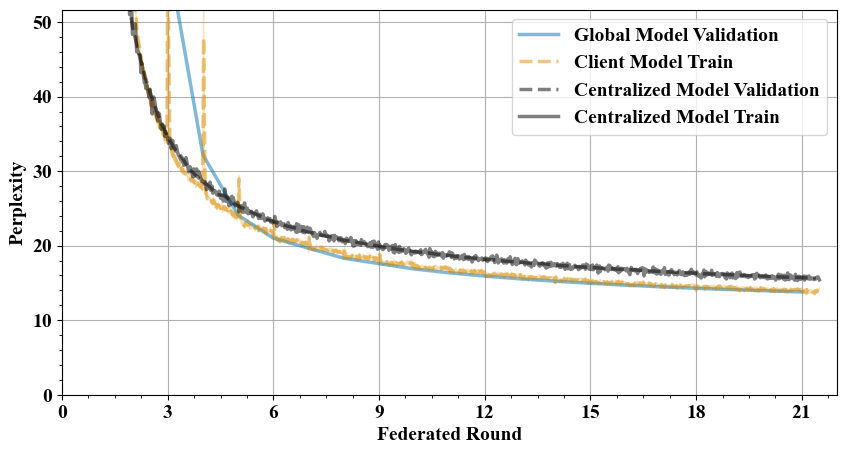

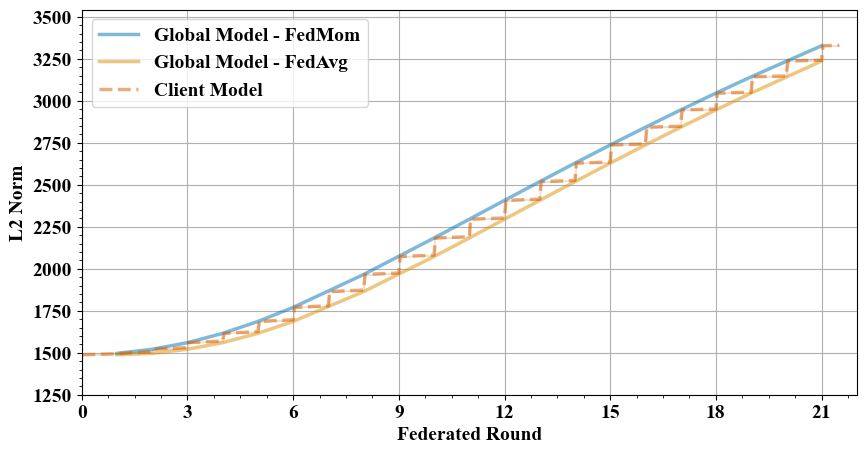

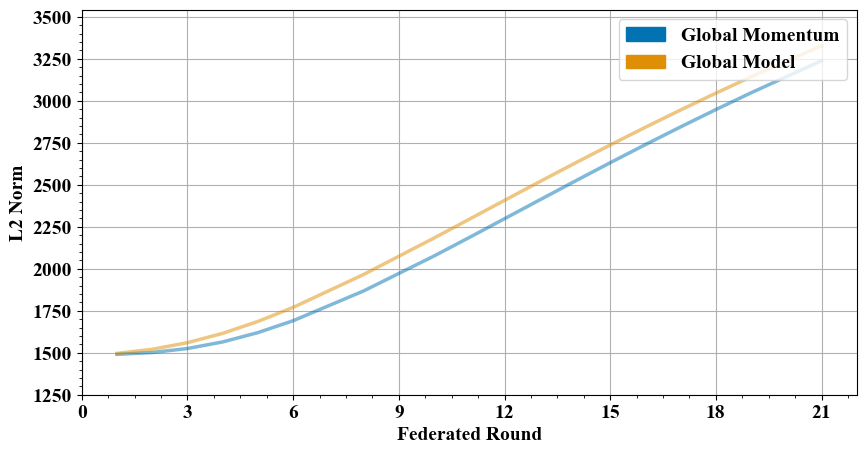

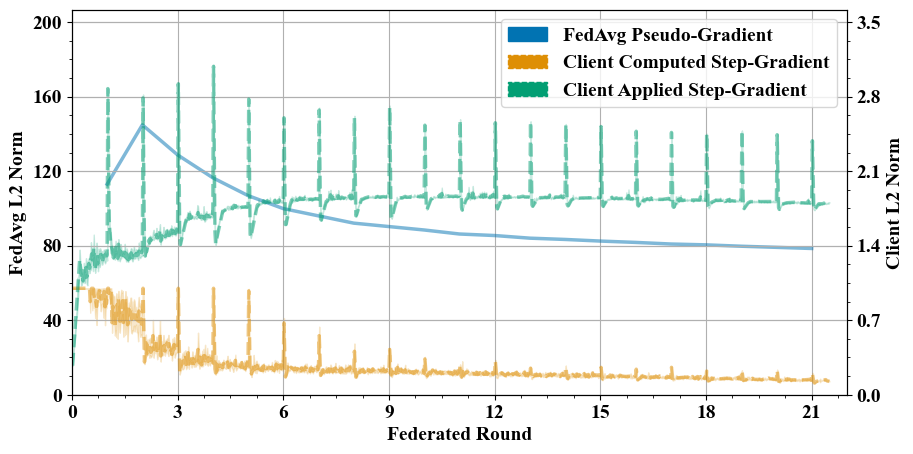

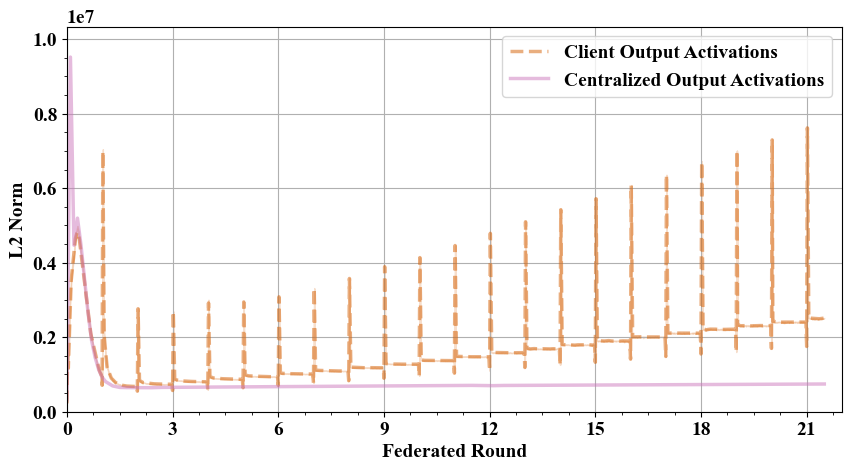

In [20]:
# ---- 7B ---- #
server_data_frame: pd.DataFrame | None = None
clients_data_frame: pd.DataFrame | None = None
centralized_df: pd.DataFrame | None = None
server_df_list: list[pd.DataFrame] = []
clients_df_list: list[pd.DataFrame] = []
centralized_df_list: list[pd.DataFrame] = []
file_name = "7b.pdf"
x_lim = (0.5, 21.5)
perplexity_legend_kwargs = {"loc": PlottingCosmetics.UPPER_RIGHT_POS.value}
l2_gradient_legend_kwargs = {"loc": PlottingCosmetics.UPPER_RIGHT_POS.value}
perplexity_y_lim: dict[str, float] | None = {"top": 50, "bottom": 0}
norm_y_lim: dict[str, float] | None = None
momentum_y_lim: dict[str, float] | None = None
grad_y_lim: dict[str, float] | None = {"bottom": 0, "top": 200}
grad_client_y_lim: dict[str, float] | None = {"bottom": 0, "top": 3.5}
act_out_y_lim: dict[str, float] | None = {"bottom": 0, "top": 1.0 * 1e7}
df_name = file_name.replace(".pdf", "_df")
try:
    server_data_frame = pd.read_pickle(f"server_{df_name}.pkl")
    clients_data_frame = pd.read_pickle(f"clients_{df_name}.pkl")
    centralized_df = pd.read_pickle(f"centralized_{df_name}.pkl")
except FileNotFoundError:
    for record in run_id_dict["fed-7B"]:
        data_frames = download_metrics(*record)
        server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
        server_df_list.append(server_data_frame)
        clients_df_list.append(clients_data_frame)
    server_data_frame = pd.concat(server_df_list)
    clients_data_frame = pd.concat(clients_df_list)
    for record in run_id_dict["cen-7B"]:
        data_frames = download_metrics_centralized(*record)
        centralized_df_list.append(data_frames)
    centralized_df = pd.concat(centralized_df_list)
    # Dump the dataframes to pickle files
    server_data_frame.to_pickle(f"server_{df_name}.pkl")
    clients_data_frame.to_pickle(f"clients_{df_name}.pkl")
    centralized_df.to_pickle(f"centralized_{df_name}.pkl")

run_all_plotting(
    server_data_frame,
    clients_data_frame,
    centralized_df,
    file_name,
    x_lim,
    perplexity_y_lim,
    momentum_y_lim,
    grad_y_lim,
    grad_client_y_lim,
    norm_y_lim,
    act_out_y_lim,
    perplexity_legend_kwargs,
    l2_gradient_legend_kwargs,
)

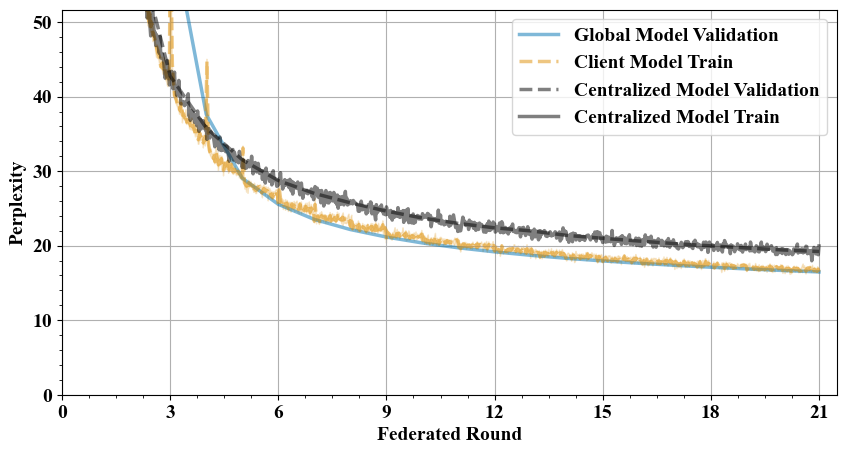

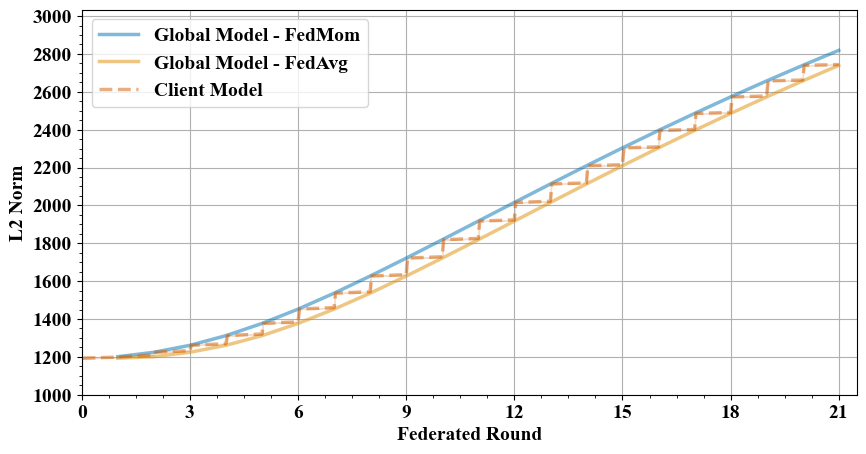

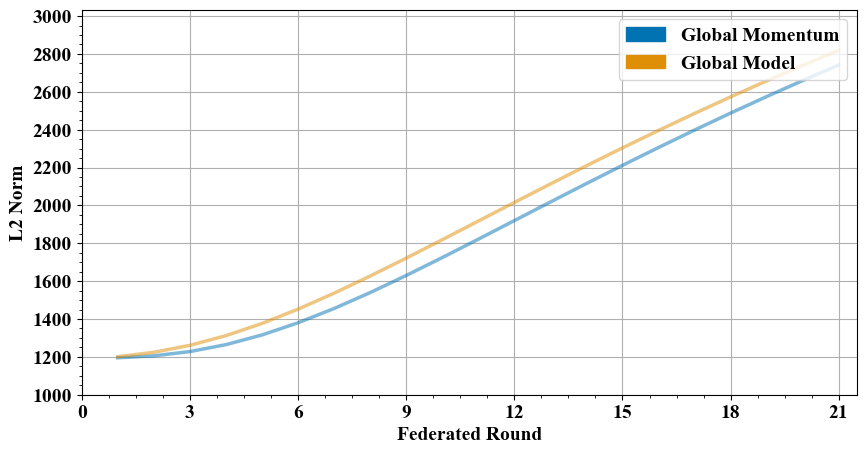

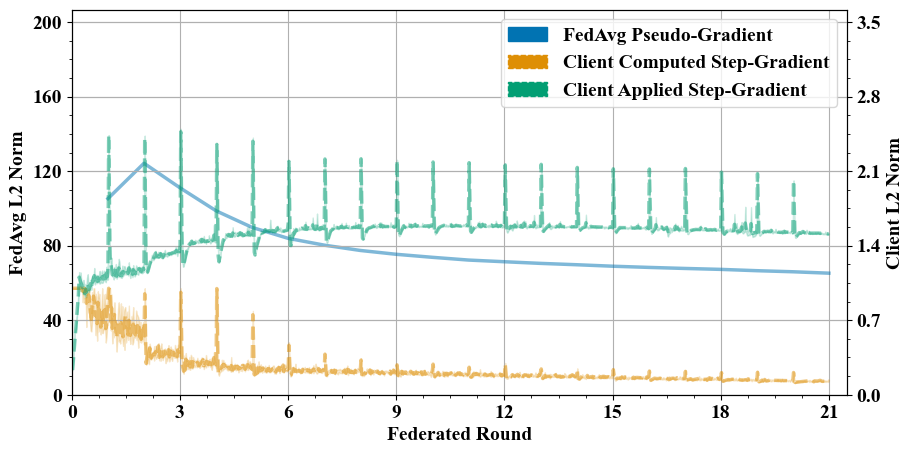

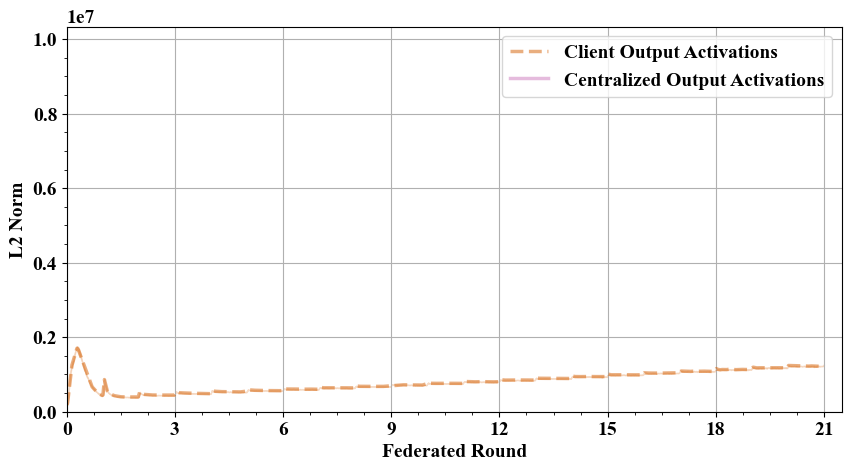

In [21]:
# ---- 3B ---- #
server_data_frame: pd.DataFrame | None = None
clients_data_frame: pd.DataFrame | None = None
centralized_df: pd.DataFrame | None = None
server_df_list: list[pd.DataFrame] = []
clients_df_list: list[pd.DataFrame] = []
centralized_df_list: list[pd.DataFrame] = []
file_name = "3b.pdf"
x_lim = (0.5, 21)
perplexity_legend_kwargs = {"loc": PlottingCosmetics.UPPER_RIGHT_POS.value}
l2_gradient_legend_kwargs = {"loc": PlottingCosmetics.UPPER_RIGHT_POS.value}
perplexity_y_lim: dict[str, float] | None = {"top": 50, "bottom": 0}
norm_y_lim: dict[str, float] | None = None
momentum_y_lim: dict[str, float] | None = None
grad_y_lim: dict[str, float] | None = {"bottom": 0, "top": 200}
grad_client_y_lim: dict[str, float] | None = {"bottom": 0, "top": 3.5}
act_out_y_lim: dict[str, float] | None = {"bottom": 0, "top": 1.0 * 1e7}
df_name = file_name.replace(".pdf", "_df")
try:
    server_data_frame = pd.read_pickle(f"server_{df_name}.pkl")
    clients_data_frame = pd.read_pickle(f"clients_{df_name}.pkl")
    centralized_df = pd.read_pickle(f"centralized_{df_name}.pkl")
except FileNotFoundError:
    for record in run_id_dict["fed-3B"]:
        data_frames = download_metrics(*record)
        server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
        server_df_list.append(server_data_frame)
        clients_df_list.append(clients_data_frame)
    server_data_frame = pd.concat(server_df_list)
    clients_data_frame = pd.concat(clients_df_list)
    for record in run_id_dict["cen-3B"]:
        data_frames = download_metrics_centralized(*record)
        centralized_df_list.append(data_frames)
    centralized_df = pd.concat(centralized_df_list)
    # Dump the dataframes to pickle files
    server_data_frame.to_pickle(f"server_{df_name}.pkl")
    clients_data_frame.to_pickle(f"clients_{df_name}.pkl")
    centralized_df.to_pickle(f"centralized_{df_name}.pkl")

run_all_plotting(
    server_data_frame,
    clients_data_frame,
    centralized_df,
    file_name,
    x_lim,
    perplexity_y_lim,
    momentum_y_lim,
    grad_y_lim,
    grad_client_y_lim,
    norm_y_lim,
    act_out_y_lim,
    perplexity_legend_kwargs,
    l2_gradient_legend_kwargs,
)

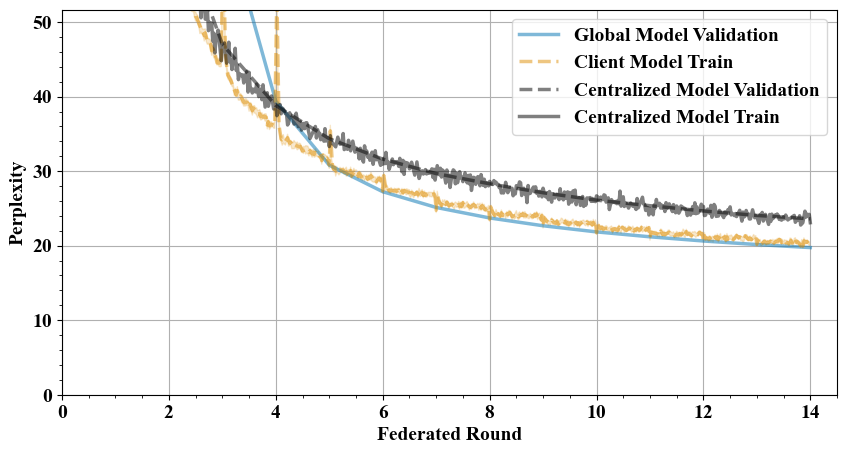

ERROR flwr 2024-10-14 16:45:04,805 | 2241876231.py:37 | No L2 model norm to plot
Traceback (most recent call last):
  File "/var/folders/z6/4xjxh_6547b23c1cn00kfg8c0000gn/T/ipykernel_8138/2241876231.py", line 29, in run_all_plotting
    plot_single_federated_run_l2_model(
  File "/var/folders/z6/4xjxh_6547b23c1cn00kfg8c0000gn/T/ipykernel_8138/4123948659.py", line 36, in plot_single_federated_run_l2_model
    sns.lineplot(
  File "/Users/lorenzosani/Library/Caches/pypoetry/virtualenvs/flower-llm-OvKrXi-2-py3.10/lib/python3.10/site-packages/seaborn/relational.py", line 485, in lineplot
    p = _LinePlotter(
  File "/Users/lorenzosani/Library/Caches/pypoetry/virtualenvs/flower-llm-OvKrXi-2-py3.10/lib/python3.10/site-packages/seaborn/relational.py", line 216, in __init__
    super().__init__(data=data, variables=variables)
  File "/Users/lorenzosani/Library/Caches/pypoetry/virtualenvs/flower-llm-OvKrXi-2-py3.10/lib/python3.10/site-packages/seaborn/_base.py", line 634, in __init__
    self.

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [22]:
# ---- 1.3B (long) ---- #
server_data_frame: pd.DataFrame | None = None
clients_data_frame: pd.DataFrame | None = None
centralized_df: pd.DataFrame | None = None
server_df_list: list[pd.DataFrame] = []
clients_df_list: list[pd.DataFrame] = []
centralized_df_list: list[pd.DataFrame] = []
file_name = "1l.pdf"
x_lim = (0.5, 14)
perplexity_legend_kwargs = {"loc": PlottingCosmetics.UPPER_RIGHT_POS.value}
l2_gradient_legend_kwargs = {"loc": PlottingCosmetics.UPPER_RIGHT_POS.value}
df_name = file_name.replace(".pdf", "_df")
try:
    server_data_frame = pd.read_pickle(f"server_{df_name}.pkl")
    clients_data_frame = pd.read_pickle(f"clients_{df_name}.pkl")
    centralized_df = pd.read_pickle(f"centralized_{df_name}.pkl")
except FileNotFoundError:
    for record in run_id_dict["fed-1B-long"]:
        data_frames = download_metrics(*record)
        server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
        server_df_list.append(server_data_frame)
        clients_df_list.append(clients_data_frame)
    server_data_frame = pd.concat(server_df_list)
    clients_data_frame = pd.concat(clients_df_list)
    for record in run_id_dict["cen-1B"]:
        data_frames = download_metrics_centralized(*record)
        centralized_df_list.append(data_frames)
    centralized_df = pd.concat(centralized_df_list)
    # Dump the dataframes to pickle files
    server_data_frame.to_pickle(f"server_{df_name}.pkl")
    clients_data_frame.to_pickle(f"clients_{df_name}.pkl")
    centralized_df.to_pickle(f"centralized_{df_name}.pkl")

run_all_plotting(
    server_data_frame,
    clients_data_frame,
    centralized_df,
    file_name,
    x_lim,
    perplexity_y_lim,
    momentum_y_lim,
    grad_y_lim,
    grad_client_y_lim,
    norm_y_lim,
    act_out_y_lim,
    perplexity_legend_kwargs,
    l2_gradient_legend_kwargs,
)

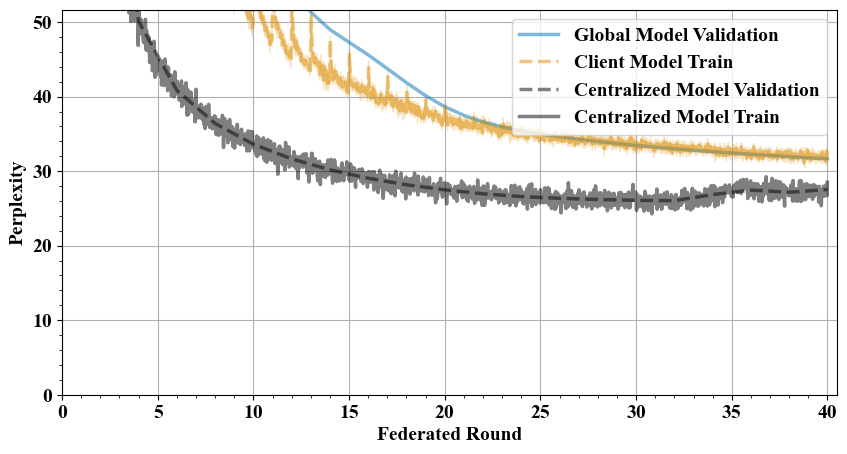

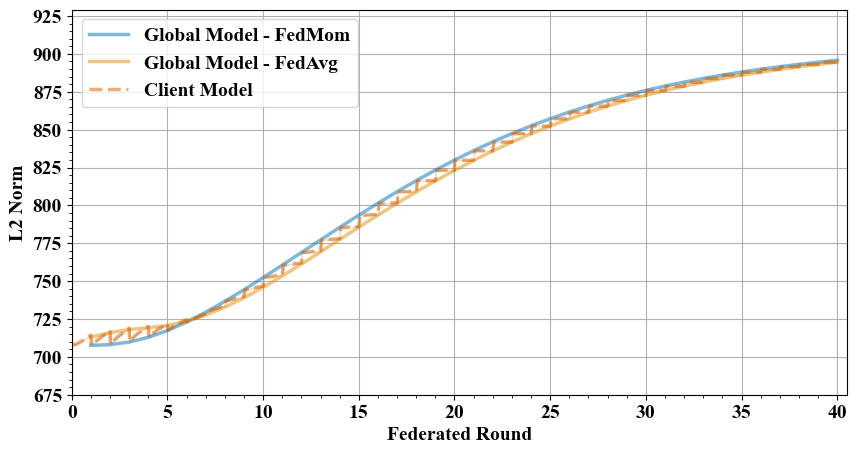

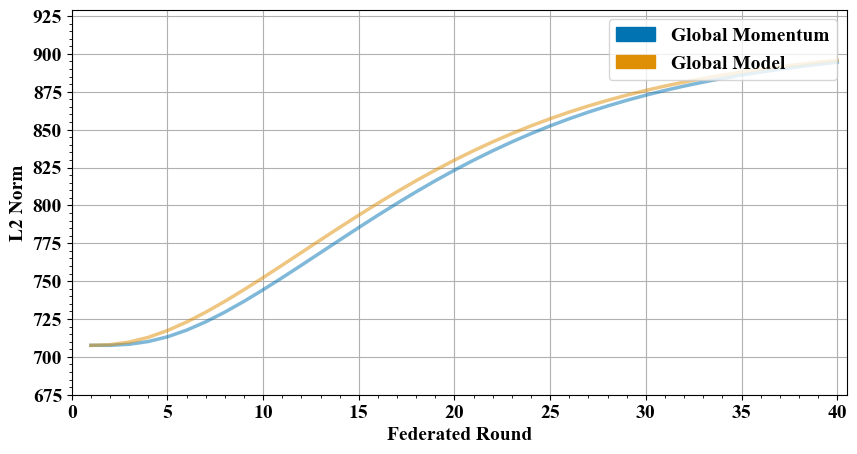

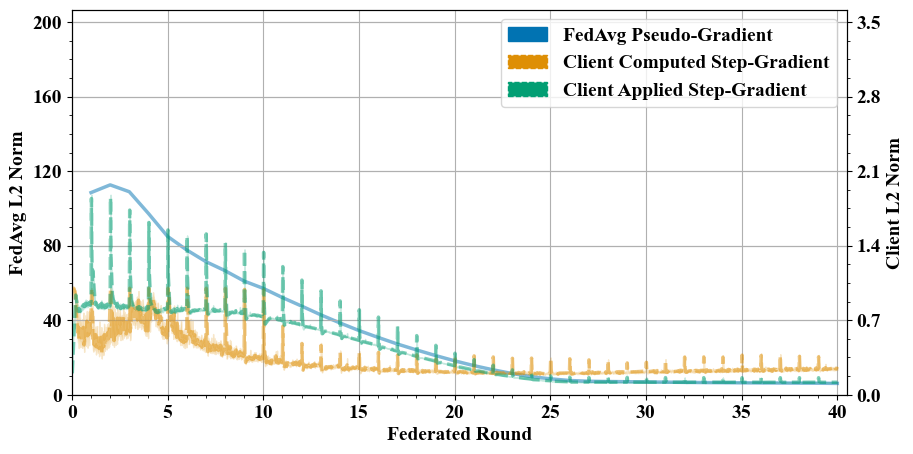

ERROR flwr 2024-10-14 16:46:15,624 | 2241876231.py:74 | No output activation norm to plot
Traceback (most recent call last):
  File "/var/folders/z6/4xjxh_6547b23c1cn00kfg8c0000gn/T/ipykernel_8138/2241876231.py", line 66, in run_all_plotting
    plot_single_federated_run_output_activation(
  File "/var/folders/z6/4xjxh_6547b23c1cn00kfg8c0000gn/T/ipykernel_8138/1747344026.py", line 54, in plot_single_federated_run_output_activation
    sns.lineplot(
  File "/Users/lorenzosani/Library/Caches/pypoetry/virtualenvs/flower-llm-OvKrXi-2-py3.10/lib/python3.10/site-packages/seaborn/relational.py", line 485, in lineplot
    p = _LinePlotter(
  File "/Users/lorenzosani/Library/Caches/pypoetry/virtualenvs/flower-llm-OvKrXi-2-py3.10/lib/python3.10/site-packages/seaborn/relational.py", line 216, in __init__
    super().__init__(data=data, variables=variables)
  File "/Users/lorenzosani/Library/Caches/pypoetry/virtualenvs/flower-llm-OvKrXi-2-py3.10/lib/python3.10/site-packages/seaborn/_base.py", line

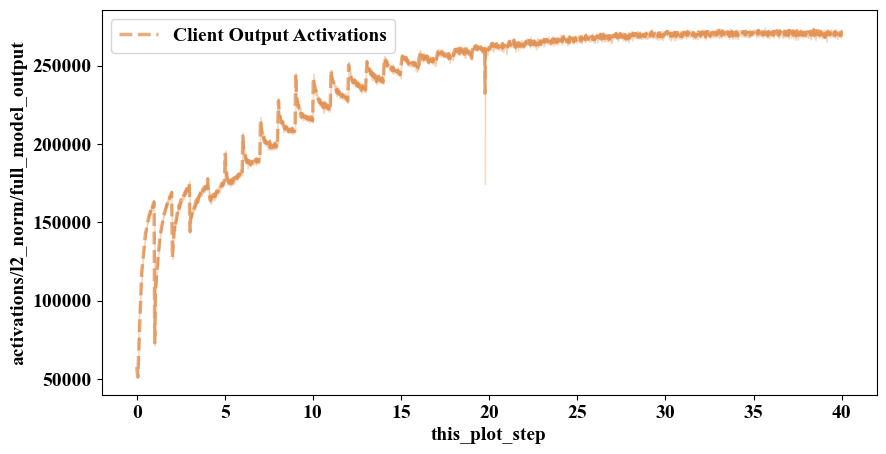

In [23]:
# ---- 350M ---- #
server_data_frame: pd.DataFrame | None = None
clients_data_frame: pd.DataFrame | None = None
centralized_df: pd.DataFrame | None = None
server_df_list: list[pd.DataFrame] = []
clients_df_list: list[pd.DataFrame] = []
centralized_df_list: list[pd.DataFrame] = []
centralized_df_list: list[pd.DataFrame] = []
file_name = "350.pdf"
x_lim = (0.5, 40)
perplexity_legend_kwargs = {"loc": PlottingCosmetics.UPPER_RIGHT_POS.value}
l2_gradient_legend_kwargs = {"loc": PlottingCosmetics.UPPER_RIGHT_POS.value}
df_name = file_name.replace(".pdf", "_df")
try:
    server_data_frame = pd.read_pickle(f"server_{df_name}.pkl")
    clients_data_frame = pd.read_pickle(f"clients_{df_name}.pkl")
    centralized_df = pd.read_pickle(f"centralized_{df_name}.pkl")
except FileNotFoundError:
    for record in run_id_dict["fed-350M"]:
        data_frames = download_metrics(record[0], record[1])
        server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
        server_df_list.append(server_data_frame)
        clients_df_list.append(clients_data_frame)
    server_data_frame = pd.concat(server_df_list)
    clients_data_frame = pd.concat(clients_df_list)
    for record in run_id_dict["cen-350M"]:
        data_frames = download_metrics_centralized(*record)
        centralized_df_list.append(data_frames)
    centralized_df = pd.concat(centralized_df_list)
    # Dump the dataframes to pickle files
    server_data_frame.to_pickle(f"server_{df_name}.pkl")
    clients_data_frame.to_pickle(f"clients_{df_name}.pkl")
    centralized_df.to_pickle(f"centralized_{df_name}.pkl")

run_all_plotting(
    server_data_frame,
    clients_data_frame,
    centralized_df,
    file_name,
    x_lim,
    perplexity_y_lim,
    momentum_y_lim,
    grad_y_lim,
    grad_client_y_lim,
    norm_y_lim,
    act_out_y_lim,
    perplexity_legend_kwargs,
    l2_gradient_legend_kwargs,
)

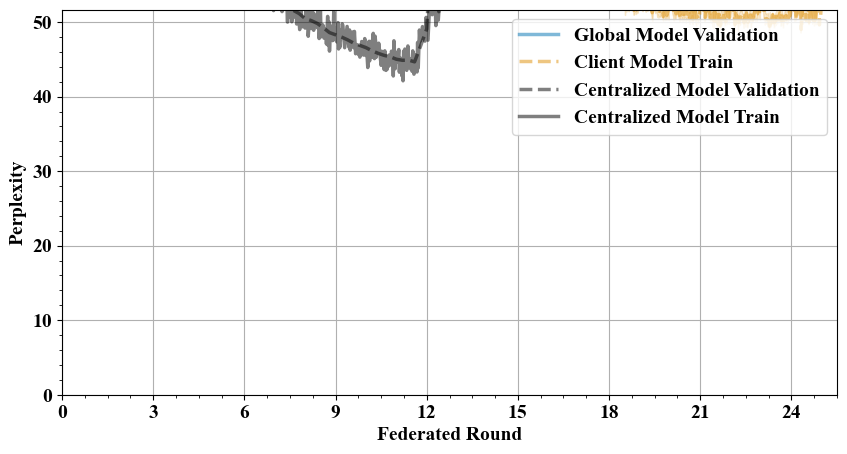

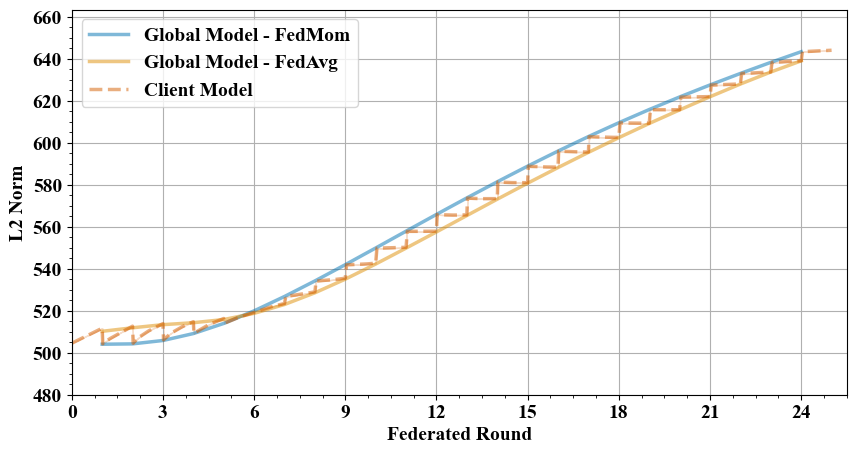

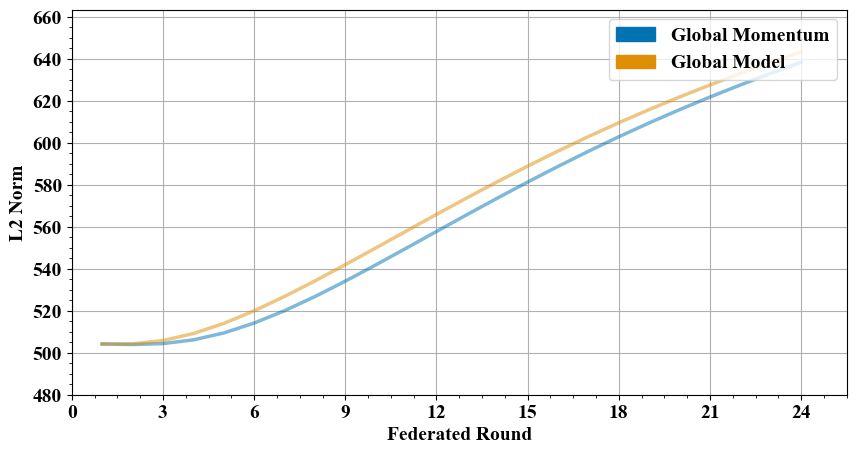

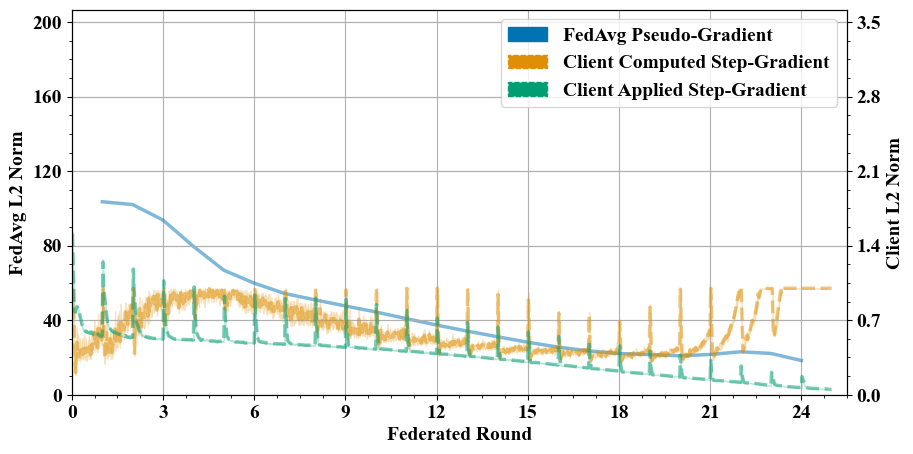

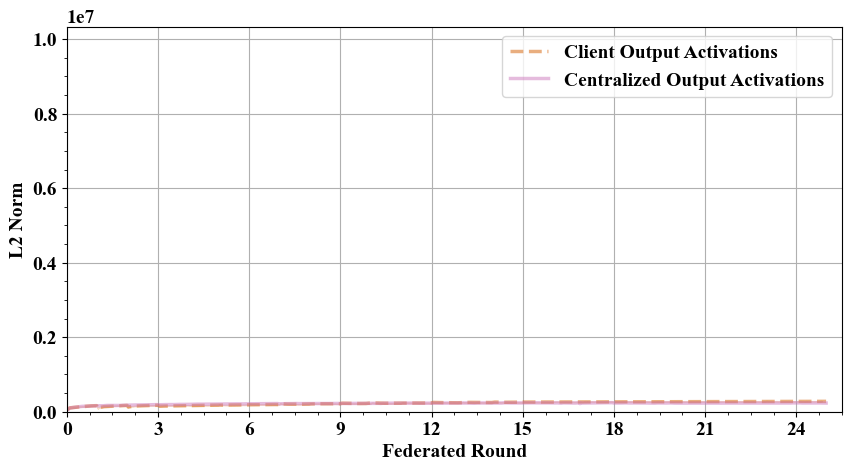

In [24]:
# ---- 125M ---- #
server_data_frame: pd.DataFrame | None = None
clients_data_frame: pd.DataFrame | None = None
centralized_df: pd.DataFrame | None = None
server_df_list: list[pd.DataFrame] = []
clients_df_list: list[pd.DataFrame] = []
centralized_df_list: list[pd.DataFrame] = []
centralized_df_list: list[pd.DataFrame] = []
file_name = "125.pdf"
x_lim = (0.5, 25)
perplexity_legend_kwargs = {"loc": PlottingCosmetics.UPPER_RIGHT_POS.value}
l2_gradient_legend_kwargs = {"loc": PlottingCosmetics.UPPER_RIGHT_POS.value}
df_name = file_name.replace(".pdf", "_df")
try:
    server_data_frame = pd.read_pickle(f"server_{df_name}.pkl")
    clients_data_frame = pd.read_pickle(f"clients_{df_name}.pkl")
    centralized_df = pd.read_pickle(f"centralized_{df_name}.pkl")
except FileNotFoundError:
    for record in run_id_dict["fed-125M"]:
        data_frames = download_metrics(record[0], record[1])
        server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
        server_df_list.append(server_data_frame)
        clients_df_list.append(clients_data_frame)
    server_data_frame = pd.concat(server_df_list)
    clients_data_frame = pd.concat(clients_df_list)
    for record in run_id_dict["cen-125M"]:
        data_frames = download_metrics_centralized(*record)
        centralized_df_list.append(data_frames)
    centralized_df = pd.concat(centralized_df_list)
    # Dump the dataframes to pickle files
    server_data_frame.to_pickle(f"server_{df_name}.pkl")
    clients_data_frame.to_pickle(f"clients_{df_name}.pkl")
    centralized_df.to_pickle(f"centralized_{df_name}.pkl")

run_all_plotting(
    server_data_frame,
    clients_data_frame,
    centralized_df,
    file_name,
    x_lim,
    perplexity_y_lim,
    momentum_y_lim,
    grad_y_lim,
    grad_client_y_lim,
    norm_y_lim,
    act_out_y_lim,
    perplexity_legend_kwargs,
    l2_gradient_legend_kwargs,
)

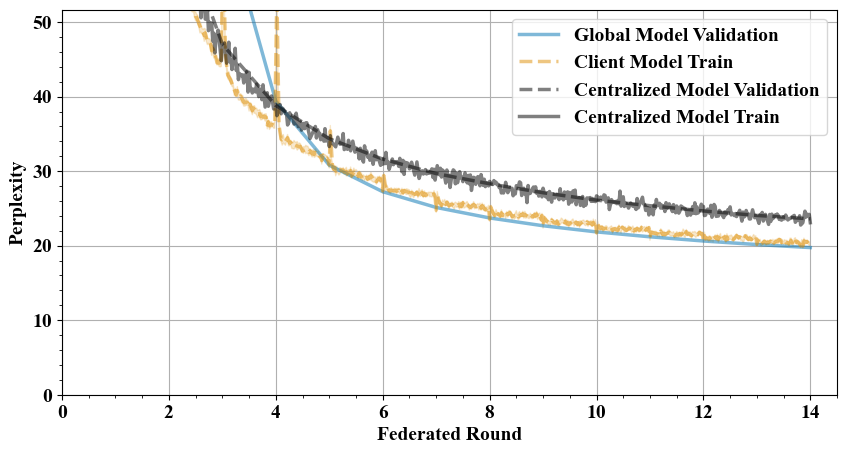

ERROR flwr 2024-10-14 16:47:04,254 | 2241876231.py:37 | No L2 model norm to plot
Traceback (most recent call last):
  File "/var/folders/z6/4xjxh_6547b23c1cn00kfg8c0000gn/T/ipykernel_8138/2241876231.py", line 29, in run_all_plotting
    plot_single_federated_run_l2_model(
  File "/var/folders/z6/4xjxh_6547b23c1cn00kfg8c0000gn/T/ipykernel_8138/4123948659.py", line 36, in plot_single_federated_run_l2_model
    sns.lineplot(
  File "/Users/lorenzosani/Library/Caches/pypoetry/virtualenvs/flower-llm-OvKrXi-2-py3.10/lib/python3.10/site-packages/seaborn/relational.py", line 485, in lineplot
    p = _LinePlotter(
  File "/Users/lorenzosani/Library/Caches/pypoetry/virtualenvs/flower-llm-OvKrXi-2-py3.10/lib/python3.10/site-packages/seaborn/relational.py", line 216, in __init__
    super().__init__(data=data, variables=variables)
  File "/Users/lorenzosani/Library/Caches/pypoetry/virtualenvs/flower-llm-OvKrXi-2-py3.10/lib/python3.10/site-packages/seaborn/_base.py", line 634, in __init__
    self.

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [25]:
# ---- 1.3B (short) ---- #
server_data_frame: pd.DataFrame | None = None
clients_data_frame: pd.DataFrame | None = None
centralized_df: pd.DataFrame | None = None
server_df_list: list[pd.DataFrame] = []
clients_df_list: list[pd.DataFrame] = []
centralized_df_list: list[pd.DataFrame] = []
file_name = "1s.pdf"
x_lim = (0.5, 14)
perplexity_legend_kwargs = {"loc": PlottingCosmetics.UPPER_RIGHT_POS.value}
l2_gradient_legend_kwargs = {"loc": PlottingCosmetics.UPPER_RIGHT_POS.value}
df_name = file_name.replace(".pdf", "_df")
try:
    server_data_frame = pd.read_pickle(f"server_{df_name}.pkl")
    clients_data_frame = pd.read_pickle(f"clients_{df_name}.pkl")
    centralized_df = pd.read_pickle(f"centralized_{df_name}.pkl")
except FileNotFoundError:
    for record in run_id_dict["fed-1B-short"]:
        data_frames = download_metrics(record[0], record[1])
        server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
        server_df_list.append(server_data_frame)
        clients_df_list.append(clients_data_frame)
    server_data_frame = pd.concat(server_df_list)
    clients_data_frame = pd.concat(clients_df_list)
    for record in run_id_dict["cen-1B"]:
        data_frames = download_metrics_centralized(*record)
        centralized_df_list.append(data_frames)
    centralized_df = pd.concat(centralized_df_list)
    # Dump the dataframes to pickle files
    server_data_frame.to_pickle(f"server_{df_name}.pkl")
    clients_data_frame.to_pickle(f"clients_{df_name}.pkl")
    centralized_df.to_pickle(f"centralized_{df_name}.pkl")

run_all_plotting(
    server_data_frame,
    clients_data_frame,
    centralized_df,
    file_name,
    x_lim,
    perplexity_y_lim,
    momentum_y_lim,
    grad_y_lim,
    grad_client_y_lim,
    norm_y_lim,
    act_out_y_lim,
    perplexity_legend_kwargs,
    l2_gradient_legend_kwargs,
)

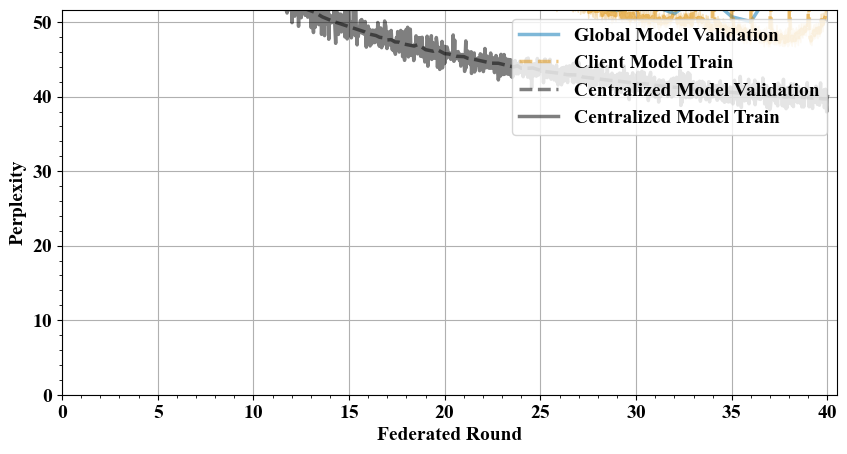

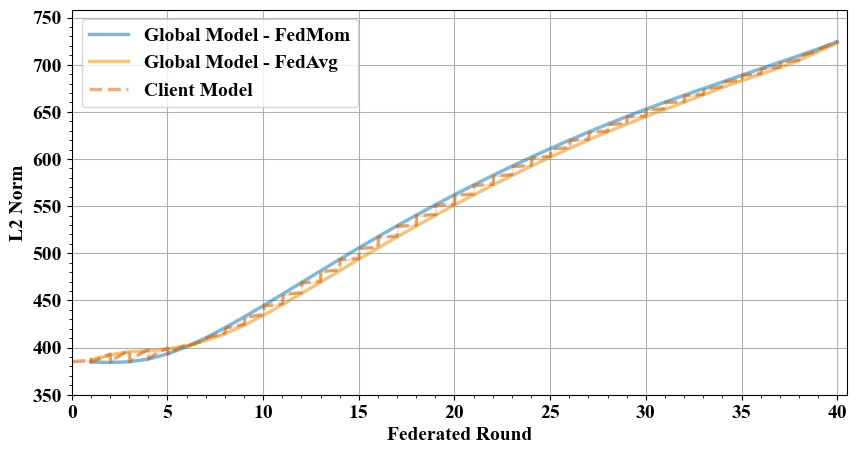

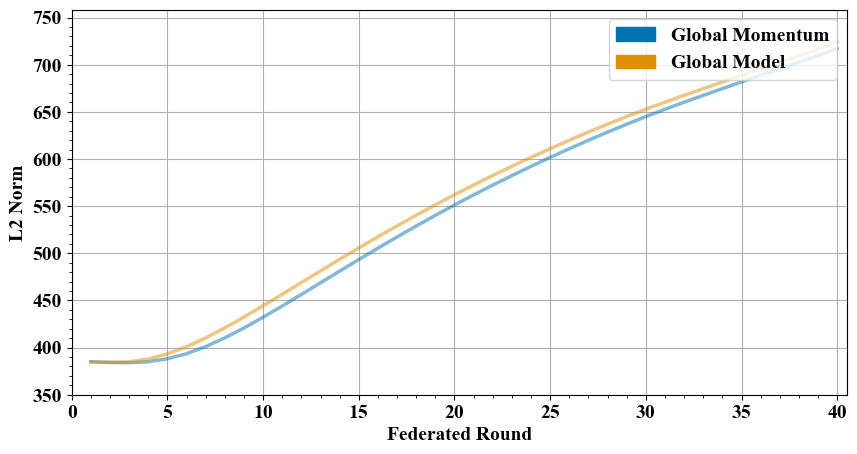

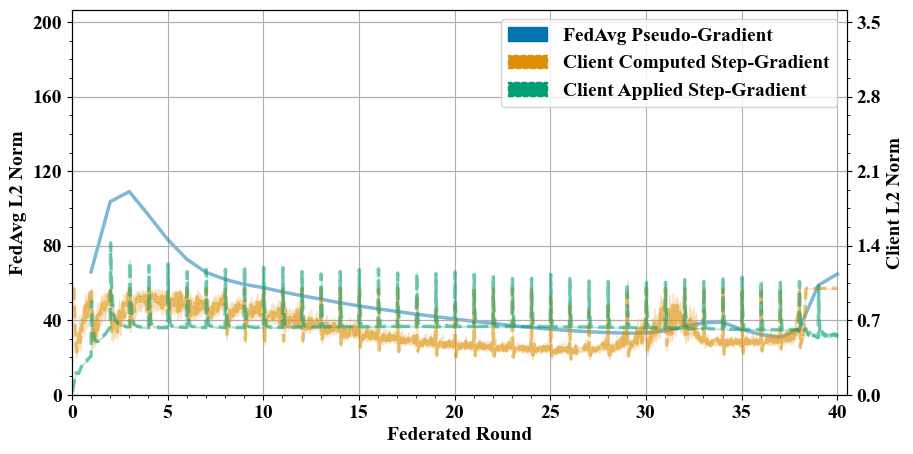

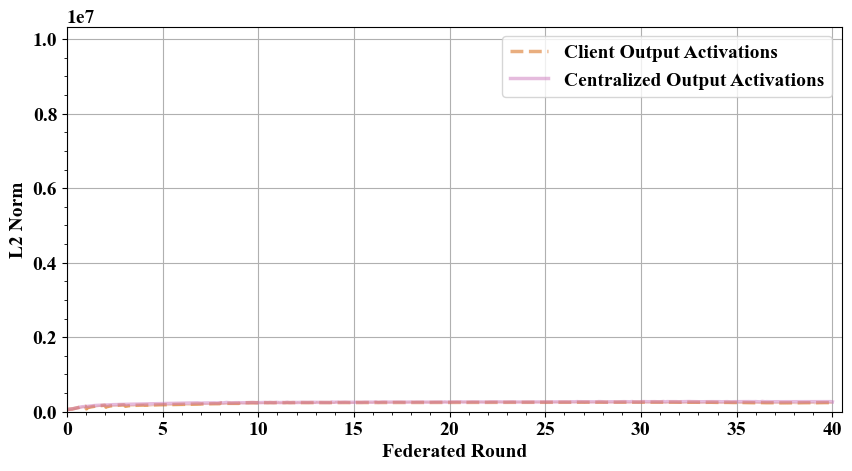

In [26]:
# ---- 75M ---- #
server_data_frame: pd.DataFrame | None = None
clients_data_frame: pd.DataFrame | None = None
centralized_df: pd.DataFrame | None = None
file_name = "75.pdf"
x_lim = (0.5, 40)
perplexity_legend_kwargs = {"loc": PlottingCosmetics.UPPER_RIGHT_POS.value}
l2_gradient_legend_kwargs = {"loc": PlottingCosmetics.UPPER_RIGHT_POS.value}
server_df_list: list[pd.DataFrame] = []
clients_df_list: list[pd.DataFrame] = []
centralized_df_list: list[pd.DataFrame] = []
df_name = file_name.replace(".pdf", "_df")
try:
    server_data_frame = pd.read_pickle(f"server_{df_name}.pkl")
    clients_data_frame = pd.read_pickle(f"clients_{df_name}.pkl")
    centralized_df = pd.read_pickle(f"centralized_{df_name}.pkl")
except FileNotFoundError:
    for record in run_id_dict["fed-75M"]:
        data_frames = download_metrics(record[0], record[1])
        server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
        server_df_list.append(server_data_frame)
        clients_df_list.append(clients_data_frame)
    server_data_frame = pd.concat(server_df_list)
    clients_data_frame = pd.concat(clients_df_list)
    for record in run_id_dict["cen-75M"]:
        data_frames = download_metrics_centralized(*record)
        centralized_df_list.append(data_frames)
    centralized_df = pd.concat(centralized_df_list)
    # Dump the dataframes to pickle files
    server_data_frame.to_pickle(f"server_{df_name}.pkl")
    clients_data_frame.to_pickle(f"clients_{df_name}.pkl")
    centralized_df.to_pickle(f"centralized_{df_name}.pkl")

run_all_plotting(
    server_data_frame,
    clients_data_frame,
    centralized_df,
    file_name,
    x_lim,
    perplexity_y_lim,
    momentum_y_lim,
    grad_y_lim,
    grad_client_y_lim,
    norm_y_lim,
    act_out_y_lim,
    perplexity_legend_kwargs,
    l2_gradient_legend_kwargs,
)

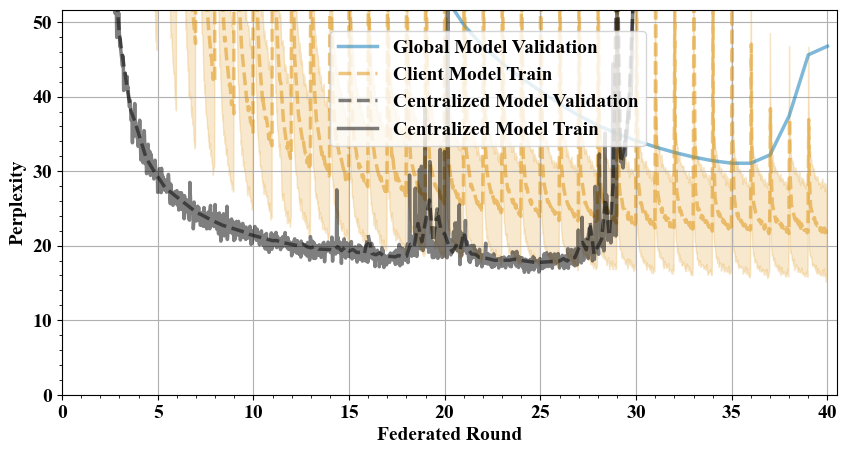

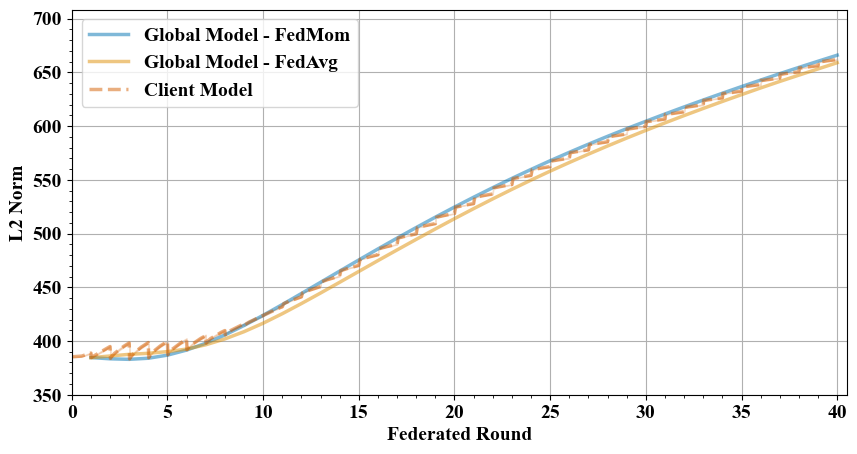

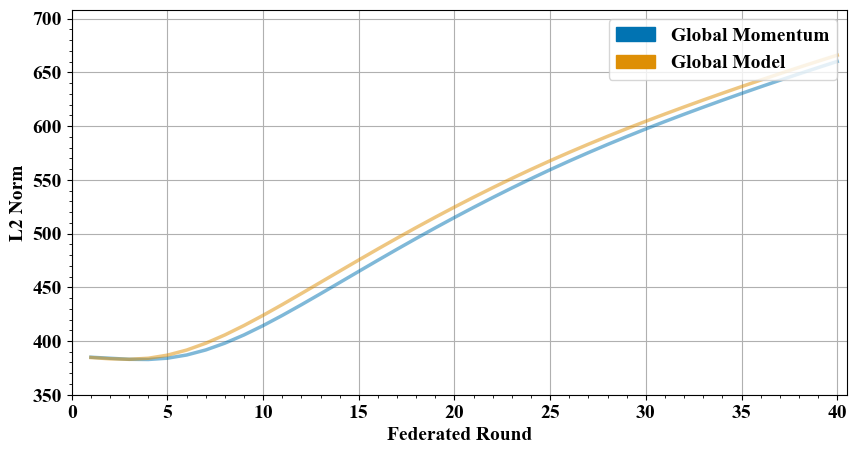

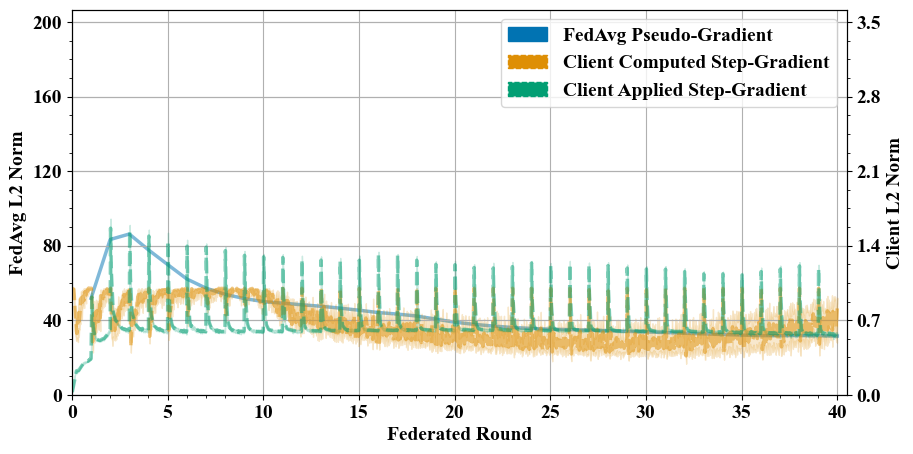

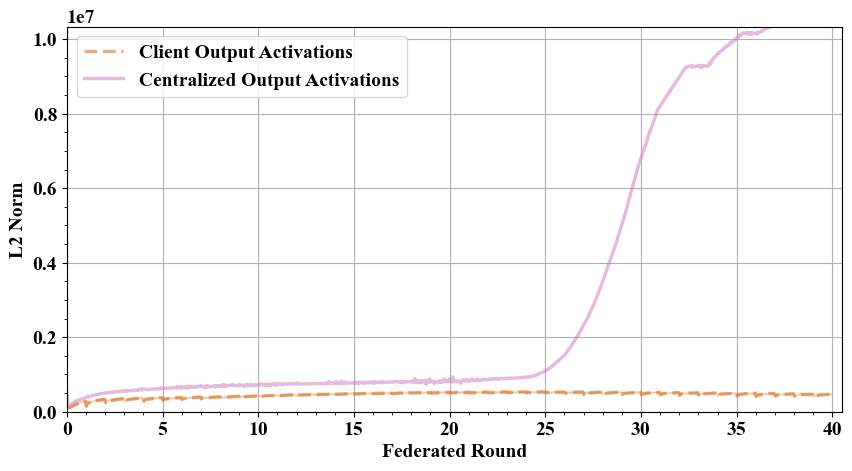

In [27]:
# ---- 75M (pile) ---- #
server_data_frame: pd.DataFrame | None = None
clients_data_frame: pd.DataFrame | None = None
centralized_df: pd.DataFrame | None = None
file_name = "pile-75.pdf"
x_lim = (0.5, 40)
perplexity_legend_kwargs = {
    "loc": PlottingCosmetics.UPPER_CENTER_POS.value,
    "bbox_to_anchor": (0.55, 0.97),
}
l2_gradient_legend_kwargs = {"loc": PlottingCosmetics.UPPER_RIGHT_POS.value}
server_df_list: list[pd.DataFrame] = []
clients_df_list: list[pd.DataFrame] = []
centralized_df_list: list[pd.DataFrame] = []
df_name = file_name.replace(".pdf", "_df")
try:
    server_data_frame = pd.read_pickle(f"server_{df_name}.pkl")
    clients_data_frame = pd.read_pickle(f"clients_{df_name}.pkl")
    centralized_df = pd.read_pickle(f"centralized_{df_name}.pkl")
except FileNotFoundError:
    for record in run_id_dict["fed-pile-75M-8"]:
        data_frames = download_metrics(*record)
        server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
        server_df_list.append(server_data_frame)
        clients_df_list.append(clients_data_frame)
    server_data_frame = pd.concat(server_df_list)
    clients_data_frame = pd.concat(clients_df_list)
    for record in run_id_dict["cen-pile-75M-8"]:
        data_frames = download_metrics_centralized(*record)
        centralized_df_list.append(data_frames)
    centralized_df = pd.concat(centralized_df_list)
    # Dump the dataframes to pickle files
    server_data_frame.to_pickle(f"server_{df_name}.pkl")
    clients_data_frame.to_pickle(f"clients_{df_name}.pkl")
    centralized_df.to_pickle(f"centralized_{df_name}.pkl")

run_all_plotting(
    server_data_frame,
    clients_data_frame,
    centralized_df,
    file_name,
    x_lim,
    perplexity_y_lim,
    momentum_y_lim,
    grad_y_lim,
    grad_client_y_lim,
    norm_y_lim,
    act_out_y_lim,
    perplexity_legend_kwargs,
    l2_gradient_legend_kwargs,
)

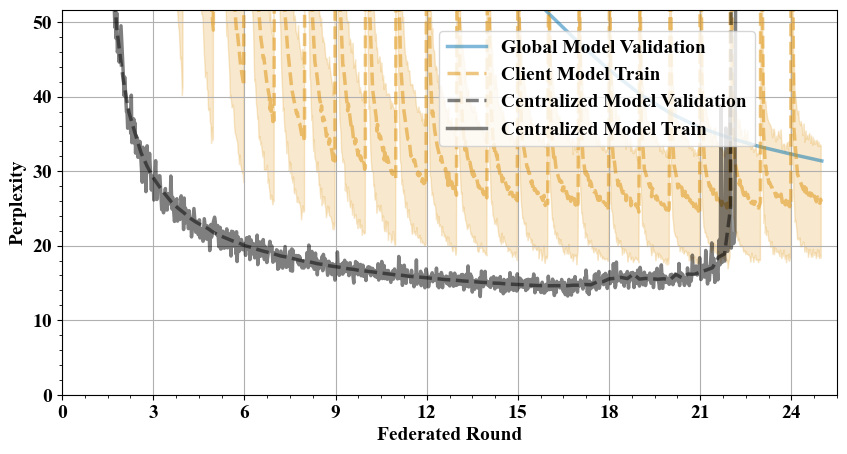

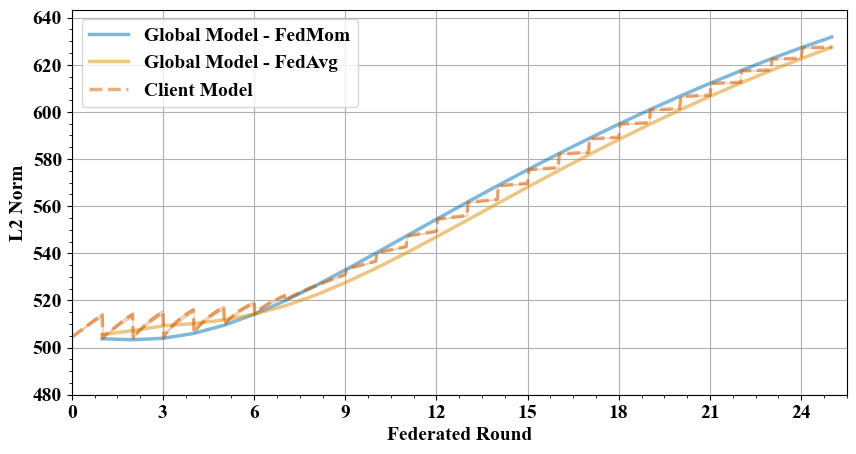

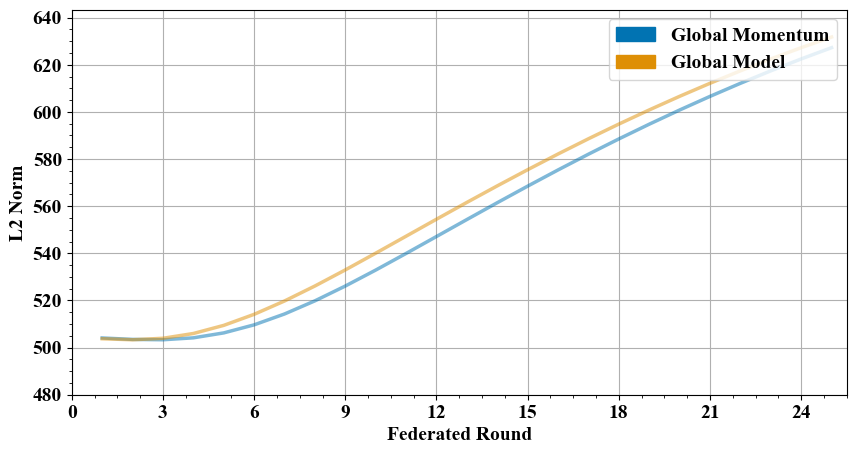

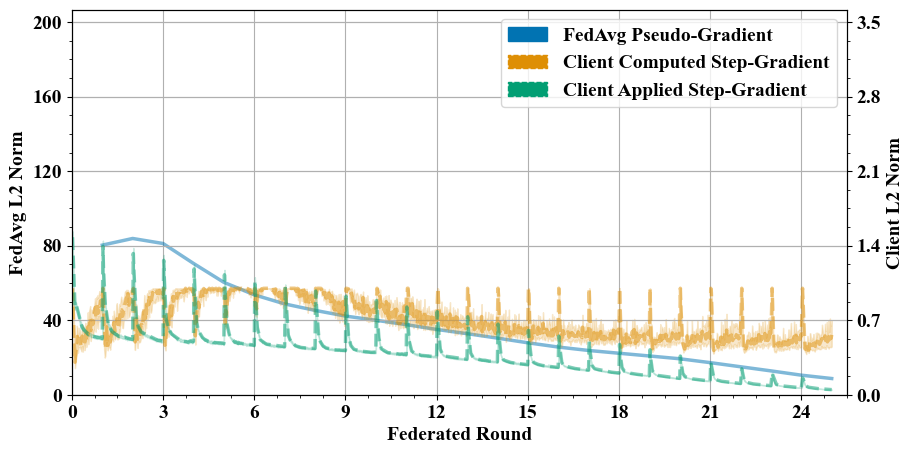

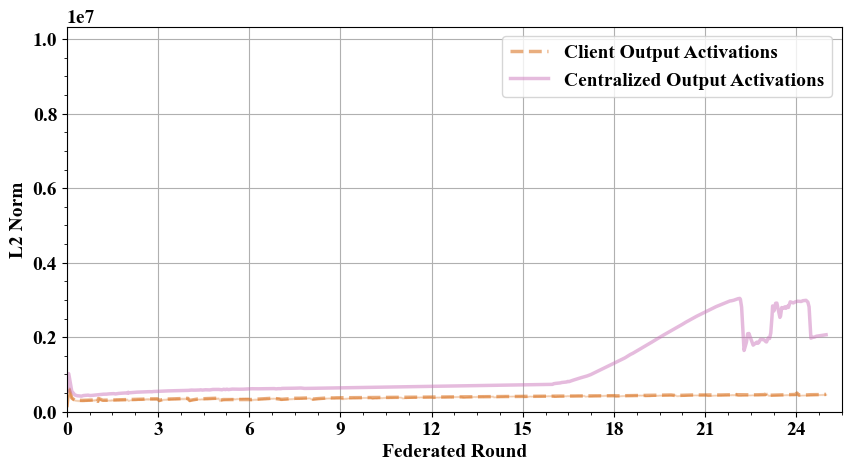

In [28]:
# ---- 125M (pile) ---- #
server_data_frame: pd.DataFrame | None = None
clients_data_frame: pd.DataFrame | None = None
centralized_df: pd.DataFrame | None = None
file_name = "pile-125.pdf"
x_lim = (0.5, 25)
perplexity_legend_kwargs = {
    "loc": PlottingCosmetics.UPPER_CENTER_POS.value,
    "bbox_to_anchor": (0.69, 0.97),
}
l2_gradient_legend_kwargs = {"loc": PlottingCosmetics.UPPER_RIGHT_POS.value}
server_df_list: list[pd.DataFrame] = []
clients_df_list: list[pd.DataFrame] = []
centralized_df_list: list[pd.DataFrame] = []
df_name = file_name.replace(".pdf", "_df")
try:
    server_data_frame = pd.read_pickle(f"server_{df_name}.pkl")
    clients_data_frame = pd.read_pickle(f"clients_{df_name}.pkl")
    centralized_df = pd.read_pickle(f"centralized_{df_name}.pkl")
except FileNotFoundError:
    for record in run_id_dict["fed-pile-125M-8"]:
        data_frames = download_metrics(*record)
        server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
        server_df_list.append(server_data_frame)
        clients_df_list.append(clients_data_frame)
    server_data_frame = pd.concat(server_df_list)
    clients_data_frame = pd.concat(clients_df_list)
    for record in run_id_dict["cen-pile-125M-8"]:
        data_frames = download_metrics_centralized(*record)
        centralized_df_list.append(data_frames)
    centralized_df = pd.concat(centralized_df_list)
    # Dump the dataframes to pickle files
    server_data_frame.to_pickle(f"server_{df_name}.pkl")
    clients_data_frame.to_pickle(f"clients_{df_name}.pkl")
    centralized_df.to_pickle(f"centralized_{df_name}.pkl")

run_all_plotting(
    server_data_frame,
    clients_data_frame,
    centralized_df,
    file_name,
    x_lim,
    perplexity_y_lim,
    momentum_y_lim,
    grad_y_lim,
    grad_client_y_lim,
    norm_y_lim,
    act_out_y_lim,
    perplexity_legend_kwargs,
    l2_gradient_legend_kwargs,
)

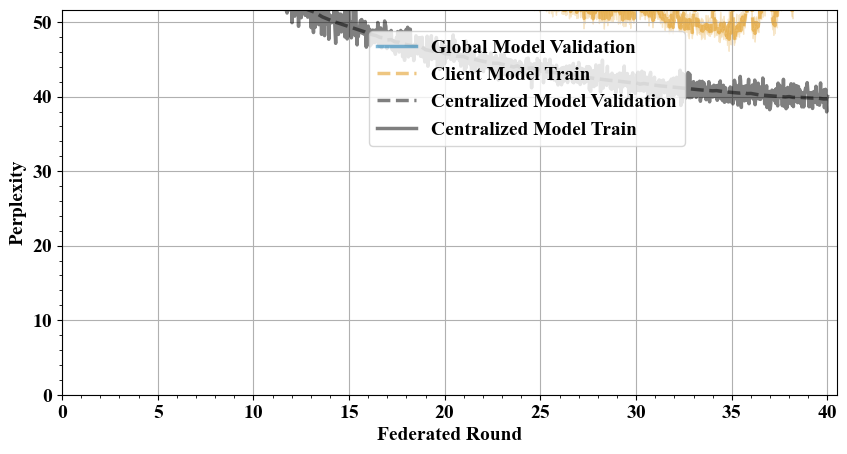

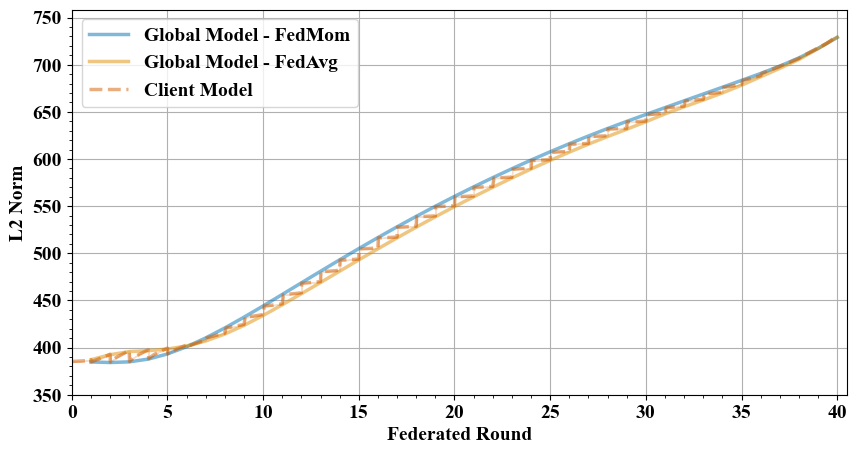

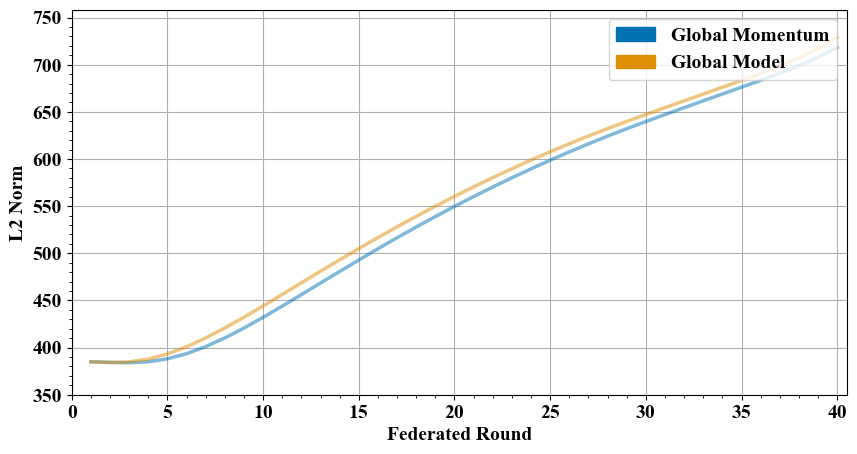

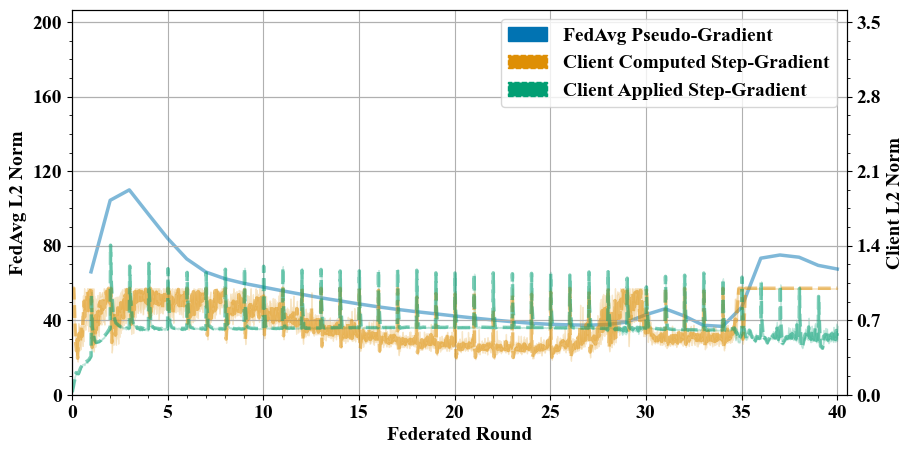

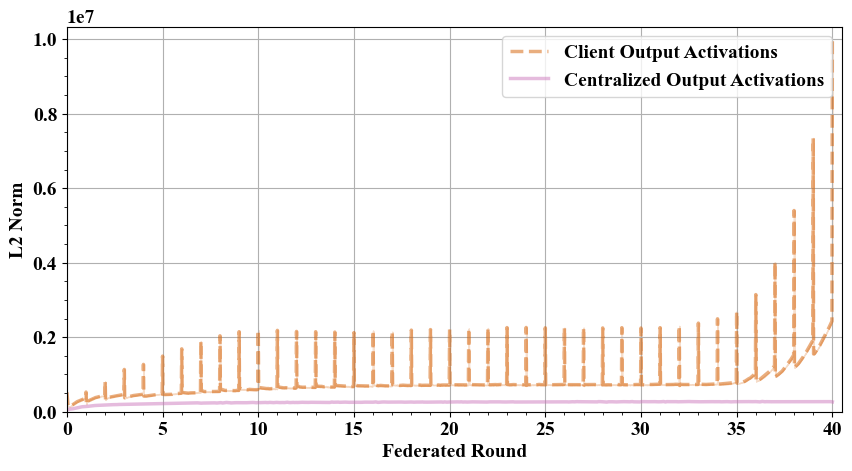

In [29]:
# ---- 75M (partial) ---- #
server_data_frame: pd.DataFrame | None = None
clients_data_frame: pd.DataFrame | None = None
centralized_df: pd.DataFrame | None = None
file_name = "partial-75.pdf"
x_lim = (0.5, 40)
perplexity_legend_kwargs = {
    "loc": PlottingCosmetics.UPPER_CENTER_POS.value,
    "bbox_to_anchor": (0.6, 0.97),
}
l2_gradient_legend_kwargs = {"loc": PlottingCosmetics.UPPER_RIGHT_POS.value}
server_df_list: list[pd.DataFrame] = []
clients_df_list: list[pd.DataFrame] = []
centralized_df_list: list[pd.DataFrame] = []
df_name = file_name.replace(".pdf", "_df")
try:
    server_data_frame = pd.read_pickle(f"server_{df_name}.pkl")
    clients_data_frame = pd.read_pickle(f"clients_{df_name}.pkl")
    centralized_df = pd.read_pickle(f"centralized_{df_name}.pkl")
except FileNotFoundError:
    for record in run_id_dict["fed-partial-75M-4_64"]:
        data_frames = download_metrics(record[0], record[1])
        server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
        server_df_list.append(server_data_frame)
        clients_df_list.append(clients_data_frame)
    server_data_frame = pd.concat(server_df_list)
    clients_data_frame = pd.concat(clients_df_list)
    for record in run_id_dict["cen-partial-75M-4_64"]:
        data_frames = download_metrics_centralized(*record)
        centralized_df_list.append(data_frames)
    centralized_df = pd.concat(centralized_df_list)
    # Dump the dataframes to pickle files
    server_data_frame.to_pickle(f"server_{df_name}.pkl")
    clients_data_frame.to_pickle(f"clients_{df_name}.pkl")
    centralized_df.to_pickle(f"centralized_{df_name}.pkl")

run_all_plotting(
    server_data_frame,
    clients_data_frame,
    centralized_df,
    file_name,
    x_lim,
    perplexity_y_lim,
    momentum_y_lim,
    grad_y_lim,
    grad_client_y_lim,
    norm_y_lim,
    act_out_y_lim,
    perplexity_legend_kwargs,
    l2_gradient_legend_kwargs,
)

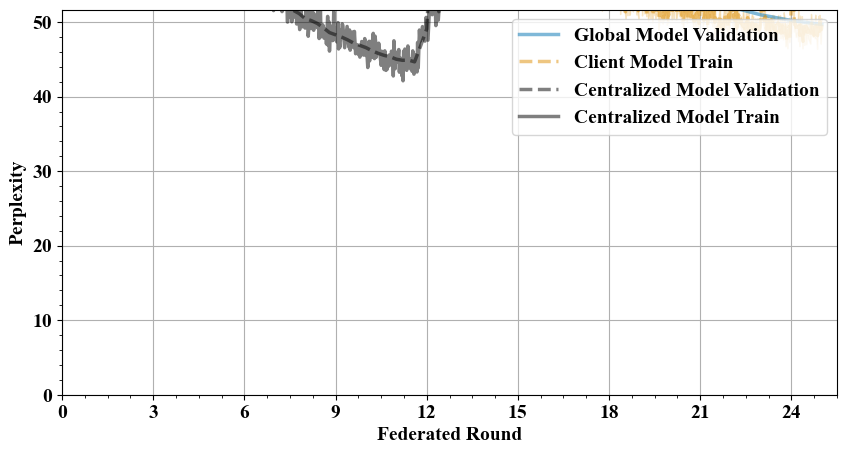

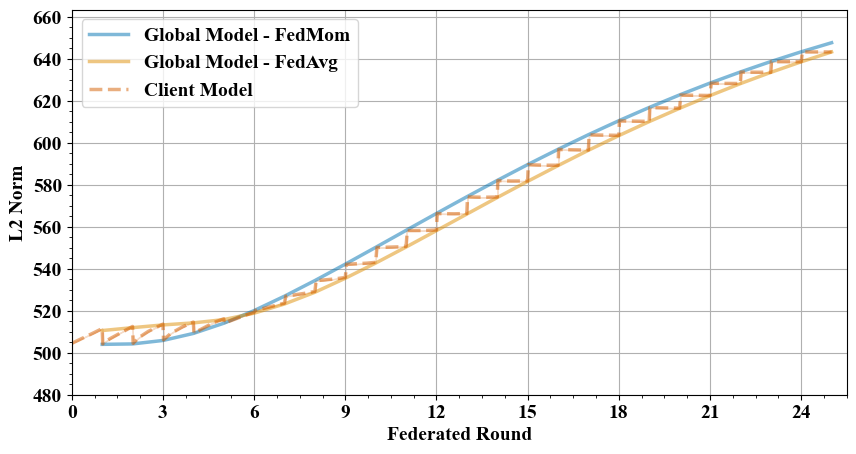

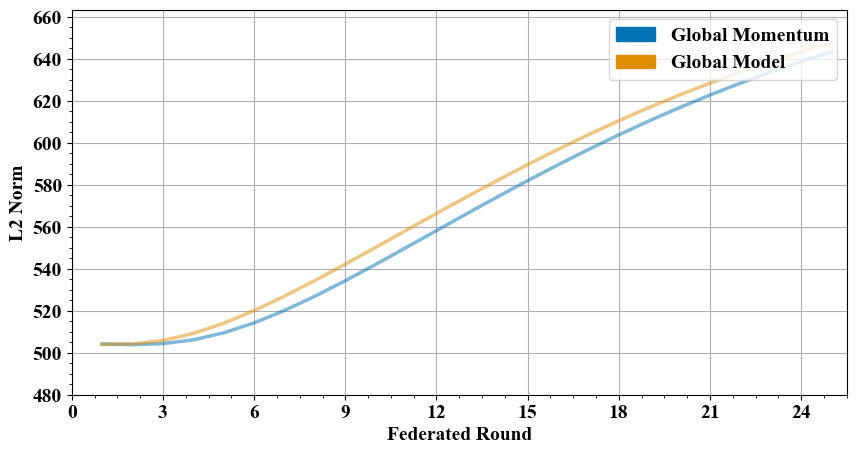

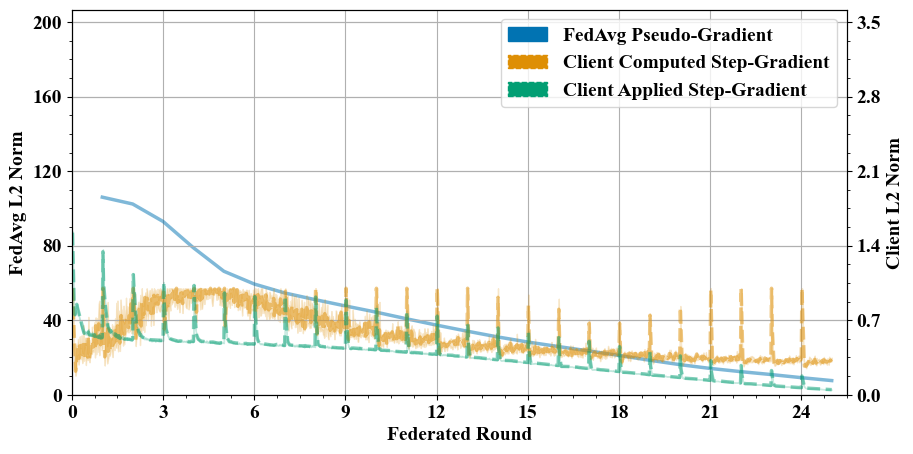

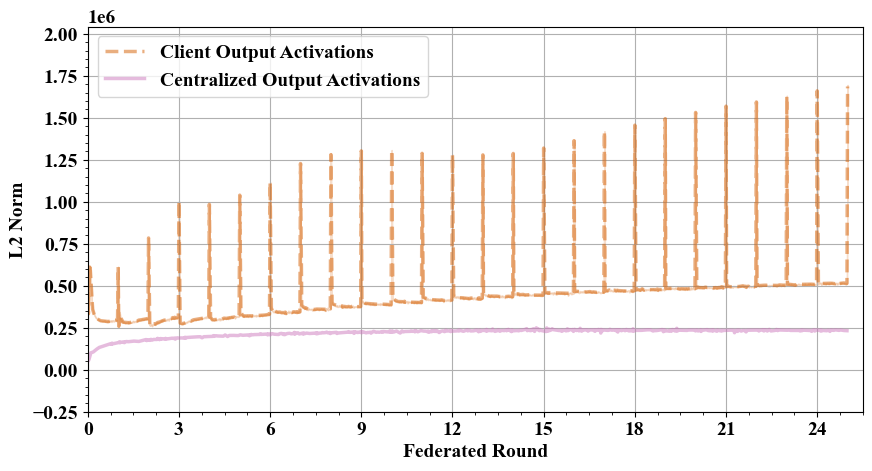

In [30]:
# ---- 125M (partial) ---- #
server_data_frame: pd.DataFrame | None = None
clients_data_frame: pd.DataFrame | None = None
centralized_df: pd.DataFrame | None = None
file_name = "partial-125.pdf"
x_lim = (0.5, 25)
perplexity_legend_kwargs = {
    "loc": PlottingCosmetics.UPPER_RIGHT_POS.value,
    # "bbox_to_anchor": (0.69, 0.97),
}
l2_gradient_legend_kwargs = {"loc": PlottingCosmetics.UPPER_RIGHT_POS.value}
act_out_y_lim: dict[str, float] | None = None
server_df_list: list[pd.DataFrame] = []
clients_df_list: list[pd.DataFrame] = []
centralized_df_list: list[pd.DataFrame] = []
df_name = file_name.replace(".pdf", "_df")
try:
    server_data_frame = pd.read_pickle(f"server_{df_name}.pkl")
    clients_data_frame = pd.read_pickle(f"clients_{df_name}.pkl")
    centralized_df = pd.read_pickle(f"centralized_{df_name}.pkl")
except FileNotFoundError:
    for record in run_id_dict["fed-partial-125M-4_64"]:
        data_frames = download_metrics(record[0], record[1])
        server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
        server_df_list.append(server_data_frame)
        clients_df_list.append(clients_data_frame)
    server_data_frame = pd.concat(server_df_list)
    clients_data_frame = pd.concat(clients_df_list)
    for record in run_id_dict["cen-partial-125M-4_64"]:
        data_frames = download_metrics_centralized(*record)
        centralized_df_list.append(data_frames)
    centralized_df = pd.concat(centralized_df_list)
    # Dump the dataframes to pickle files
    server_data_frame.to_pickle(f"server_{df_name}.pkl")
    clients_data_frame.to_pickle(f"clients_{df_name}.pkl")
    centralized_df.to_pickle(f"centralized_{df_name}.pkl")

run_all_plotting(
    server_data_frame,
    clients_data_frame,
    centralized_df,
    file_name,
    x_lim,
    perplexity_y_lim,
    momentum_y_lim,
    grad_y_lim,
    grad_client_y_lim,
    norm_y_lim,
    act_out_y_lim,
    perplexity_legend_kwargs,
    l2_gradient_legend_kwargs,
)

In [60]:
csv_path = "/Users/lorenzosani/Repositories/flower_llm/notebooks/wandb_export_2024-10-10T10_55_45.649+01_00.csv"

df = pd.read_csv(csv_path)
drop_columns = []
for column in df.columns:
    if "MIN" in column:
        drop_columns.append(column)
    if "MAX" in column:
        drop_columns.append(column)
    if "adam" in column:
        drop_columns.append(column)
    if "yogi" in column:
        drop_columns.append(column)
    if "cons" in column:
        drop_columns.append(column)
rename_columns: dict[str, str] = {}
for column in df.columns:
    if column in drop_columns:
        continue
    if "photon-75M-20240909_161333" in column:
        rename_columns[column] = column.replace(
            "run_uuid: photon-75M-20240909_161333", "FedAvg (small batches)"
        ).replace(" - metrics/train/LanguageCrossEntropy", "")
    if "diloco-75M-20240905_133735" in column:
        rename_columns[column] = column.replace(
            "run_uuid: diloco-75M-20240905_133735", "SGD+N (small batches)"
        ).replace(" - metrics/train/LanguageCrossEntropy", "")
    if "photon-75M-keep-opt-20240904_163142" in column:
        rename_columns[column] = column.replace(
            "run_uuid: photon-75M-keep-opt-20240904_163142",
            "FedAvg-KeepOpt (small batches)",
        ).replace(" - metrics/train/LanguageCrossEntropy", "")
    if "diloco-75M-20240814_090920" in column:
        rename_columns[column] = column.replace(
            "run_uuid: diloco-75M-20240814_090920", "SGD+N"
        ).replace(" - metrics/train/LanguageCrossEntropy", "")
    if "diloco-75M-fedavg-keep-opt-20240813_091613" in column:
        rename_columns[column] = column.replace(
            "run_uuid: diloco-75M-fedavg-keep-opt-20240813_091613", "FedAvg-KeepOpt"
        ).replace(" - metrics/train/LanguageCrossEntropy", "")
    if "diloco-75M-fedavg-20240807_134533" in column:
        rename_columns[column] = column.replace(
            "run_uuid: diloco-75M-fedavg-20240807_134533", "FedAvg"
        ).replace(" - metrics/train/LanguageCrossEntropy", "")
    if "diloco-cen-20240726_121649_centralised" in column:
        rename_columns[column] = column.replace(
            "run_uuid: diloco-cen-20240726_121649_centralised", "Centralized"
        ).replace(" - metrics/train/LanguageCrossEntropy", "")
df.drop(columns=drop_columns, inplace=True)
df.rename(columns=rename_columns, inplace=True)
df = df.apply(pd.to_numeric, errors="coerce")
df

/var/folders/z6/4xjxh_6547b23c1cn00kfg8c0000gn/T/ipykernel_8138/1131504900.py:3: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


,Step,FedAvg (small batches),SGD+N (small batches),FedAvg-KeepOpt (small batches),SGD+N,FedAvg-KeepOpt,FedAvg,Centralized
0,0,11.842266,11.861616,11.745079,11.770991,12.041204,11.804535,NaN
1,1,11.839119,11.853112,11.746823,11.770888,12.042991,11.804798,NaN
2,2,11.839076,11.868512,11.746357,11.768557,12.041605,11.802851,NaN
3,3,11.821607,11.836001,11.738649,11.758647,12.029604,11.789607,11.766284
4,4,11.792346,11.822004,11.713175,11.737459,12.003767,11.770839,NaN
...,...,...,...,...,...,...,...,...
44165,87957,NaN,NaN,NaN,NaN,NaN,NaN,8.550256
44166,87977,NaN,NaN,NaN,NaN,NaN,NaN,8.507427
44167,87984,NaN,NaN,NaN,NaN,NaN,NaN,8.548800
44168,87994,NaN,NaN,NaN,NaN,NaN,NaN,8.531509



run_uuid: photon-75M-20240909_161333 - Ours with reduced batch size
run_uuid: diloco-75M-20240905_133735 - SGD+Nestorov + AdamW with reduced batch size
run_uuid: photon-75M-keep-opt-20240904_163142 - Ours with reduced batch size, keeping local opt


run_uuid: diloco-75M-20240814_090920 - SGD+Nestorov + AdamW
diloco-75M-fedavg-keep-opt-20240813_091613 - Ours, keeping local opt
run_uuid: diloco-75M-fedavg-20240807_134533 - Ours

run_uuid: diloco-cen-20240726_121649_centralised - Centralised

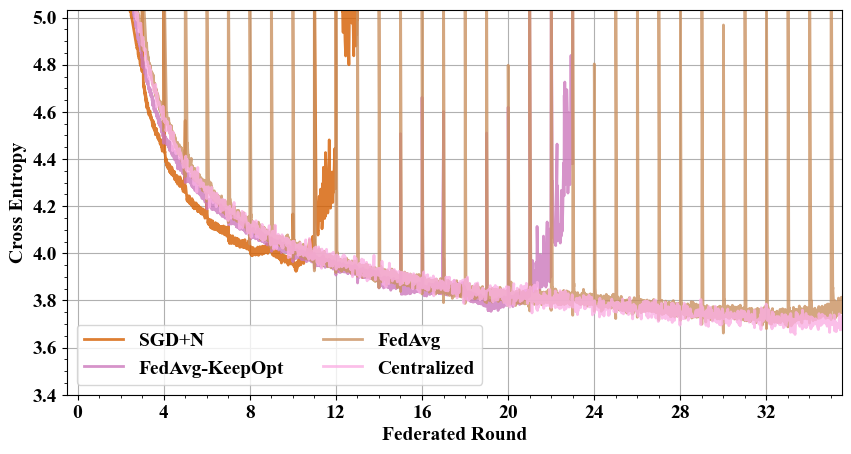

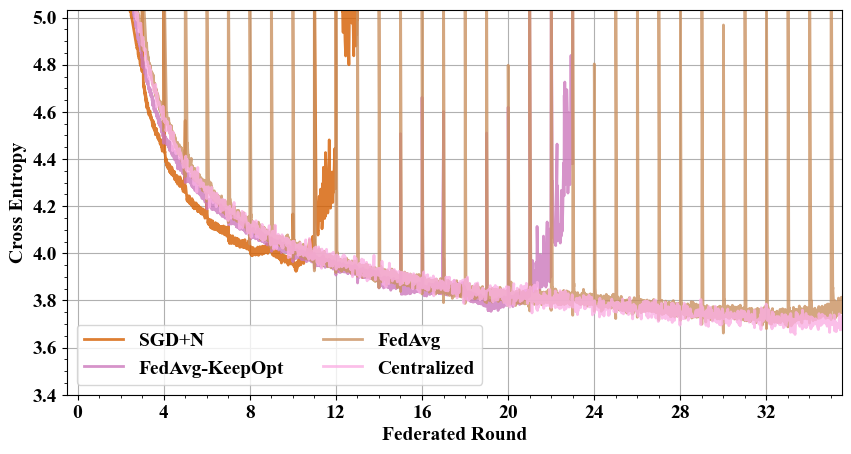

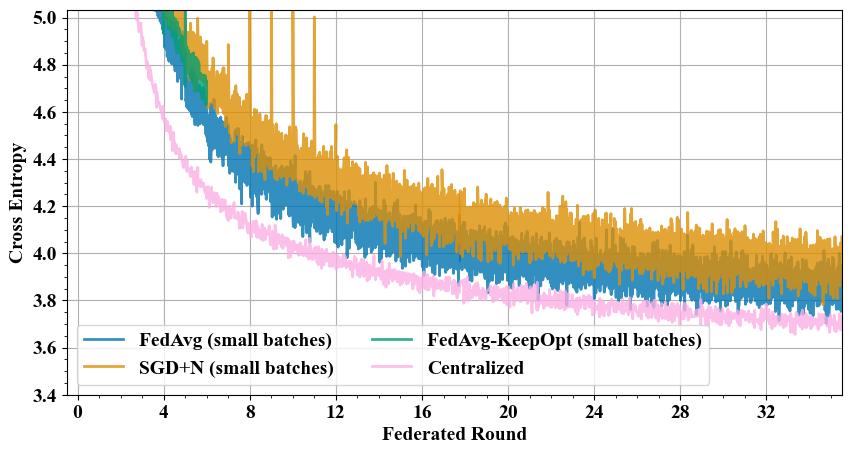

In [68]:
#! All batches
plt.figure(figsize=(10, 5))
for i, new_columns_name in enumerate(rename_columns.values()):
    if "small" in new_columns_name:
        continue
    tmp_df = df[df[new_columns_name] < 14.0][new_columns_name].dropna()
    sns.lineplot(
        x=df.loc[tmp_df.index, "Step"] / 500,
        y=tmp_df.values,
        label=new_columns_name,
        alpha=0.8,
        color=color_palette[i],
        linestyle=line_styles[0],
        linewidth=2,  # Increase line width
    )
plt.xlim([0.0 - 0.5, 35.0 + 0.5])
plt.ylim([3.5, 5.0])
# Reconcile ticks and limits
_y_ticks = plt.yticks()[0]
delta = _y_ticks[-1] - _y_ticks[-2]
plt.ylim(_y_ticks[0], _y_ticks[-1] + (1 / 6) * delta)
plt.yticks(_y_ticks)

plt.gca().yaxis.set_minor_locator(MultipleLocator(5))

# Force x-ticks to be integers
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(which="major")
plt.minorticks_on()  # Turn on the minor ticks
# Set x and y labels
plt.xlabel(AxisLabels.FED_ROUND.value)
plt.ylabel(AxisLabels.CROSS_ENTROPY.value)
# Set legend
plt.legend(ncol=2)
plt.savefig("75M_opt_ce_all.pdf", format="pdf", dpi=800, bbox_inches="tight")
# Show the figure
plt.show()

#! Large batches
plt.figure(figsize=(10, 5))
for i, new_columns_name in enumerate(rename_columns.values()):
    if "small" in new_columns_name:
        continue
    tmp_df = df[df[new_columns_name] < 14.0][new_columns_name].dropna()
    sns.lineplot(
        x=df.loc[tmp_df.index, "Step"] / 500,
        y=tmp_df.values,
        label=new_columns_name,
        alpha=0.8,
        color=color_palette[i],
        linestyle=line_styles[0],
        linewidth=2,  # Increase line width
    )
plt.xlim([0.0 - 0.5, 35.0 + 0.5])
plt.ylim([3.5, 5.0])
# Reconcile ticks and limits
_y_ticks = plt.yticks()[0]
delta = _y_ticks[-1] - _y_ticks[-2]
plt.ylim(_y_ticks[0], _y_ticks[-1] + (1 / 6) * delta)
plt.yticks(_y_ticks)

plt.gca().yaxis.set_minor_locator(MultipleLocator(5))

# Force x-ticks to be integers
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(which="major")
plt.minorticks_on()  # Turn on the minor ticks
# Set x and y labels
plt.xlabel(AxisLabels.FED_ROUND.value)
plt.ylabel(AxisLabels.CROSS_ENTROPY.value)
# Set legend
plt.legend(ncol=2)
plt.savefig("75M_opt_ce.pdf", format="pdf", dpi=800, bbox_inches="tight")
# Show the figure
plt.show()

#! Small batches
plt.figure(figsize=(10, 5))
for i, new_columns_name in enumerate(rename_columns.values()):
    if "small" in new_columns_name or "Centralized" in new_columns_name:
        tmp_df = df[df[new_columns_name] < 14.0][new_columns_name].dropna()
        sns.lineplot(
            x=df.loc[tmp_df.index, "Step"] / 500,
            y=tmp_df.values,
            label=new_columns_name,
            alpha=0.8,
            color=color_palette[i],
            linestyle=line_styles[0],
            linewidth=2,  # Increase line width
        )
plt.xlim([0.0 - 0.5, 35.0 + 0.5])
plt.ylim([3.5, 5.0])
# Reconcile ticks and limits
_y_ticks = plt.yticks()[0]
delta = _y_ticks[-1] - _y_ticks[-2]
plt.ylim(_y_ticks[0], _y_ticks[-1] + (1 / 6) * delta)
plt.yticks(_y_ticks)

plt.gca().yaxis.set_minor_locator(MultipleLocator(5))

# Force x-ticks to be integers
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(which="major")
plt.minorticks_on()  # Turn on the minor ticks
# Set x and y labels
plt.xlabel(AxisLabels.FED_ROUND.value)
plt.ylabel(AxisLabels.CROSS_ENTROPY.value)
# Set legend
plt.legend(ncol=2)
plt.savefig("75M_opt_ce_small_batches.pdf", format="pdf", dpi=800, bbox_inches="tight")
# Show the figure
plt.show()

In [75]:
csv_path = "/Users/lorenzosani/Repositories/flower_llm/notebooks/wandb_export_2024-10-14T16_41_47.148+01_00.csv"

df = pd.read_csv(csv_path)
drop_columns = []
for column in df.columns:
    if "MIN" in column:
        drop_columns.append(column)
    if "MAX" in column:
        drop_columns.append(column)
    if "adam" in column:
        drop_columns.append(column)
    if "yogi" in column:
        drop_columns.append(column)
    if "cons" in column:
        drop_columns.append(column)
rename_columns: dict[str, str] = {}
for column in df.columns:
    if column in drop_columns:
        continue
    if "photon-75M-20240909_161333" in column:
        rename_columns[column] = column.replace(
            "run_uuid: photon-75M-20240909_161333", "FedAvg (small batches)"
        ).replace(" - metrics/train/LanguagePerplexity", "")
    if "diloco-75M-20240905_133735" in column:
        rename_columns[column] = column.replace(
            "run_uuid: diloco-75M-20240905_133735", "SGD+N (small batches)"
        ).replace(" - metrics/train/LanguagePerplexity", "")
    if "photon-75M-keep-opt-20240904_163142" in column:
        rename_columns[column] = column.replace(
            "run_uuid: photon-75M-keep-opt-20240904_163142",
            "FedAvg-KeepOpt (small batches)",
        ).replace(" - metrics/train/LanguagePerplexity", "")
    if "diloco-75M-20240814_090920" in column:
        rename_columns[column] = column.replace(
            "run_uuid: diloco-75M-20240814_090920", "SGD+N"
        ).replace(" - metrics/train/LanguagePerplexity", "")
    if "diloco-75M-fedavg-keep-opt-20240813_091613" in column:
        rename_columns[column] = column.replace(
            "run_uuid: diloco-75M-fedavg-keep-opt-20240813_091613", "FedAvg-KeepOpt"
        ).replace(" - metrics/train/LanguagePerplexity", "")
    if "diloco-75M-fedavg-20240807_134533" in column:
        rename_columns[column] = column.replace(
            "run_uuid: diloco-75M-fedavg-20240807_134533", "FedAvg"
        ).replace(" - metrics/train/LanguagePerplexity", "")
    if "diloco-cen-20240726_121649_centralised" in column:
        rename_columns[column] = column.replace(
            "run_uuid: diloco-cen-20240726_121649_centralised", "Centralized"
        ).replace(" - metrics/train/LanguagePerplexity", "")
df.drop(columns=drop_columns, inplace=True)
df.rename(columns=rename_columns, inplace=True)
df = df.apply(pd.to_numeric, errors="coerce")
df

/var/folders/z6/4xjxh_6547b23c1cn00kfg8c0000gn/T/ipykernel_8138/3141431267.py:3: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


,Step,FedAvg (small batches),SGD+N (small batches),FedAvg-KeepOpt (small batches),SGD+N,FedAvg-KeepOpt,FedAvg,Centralized
0,0,138252.250000,138953.437500,126135.927734,129442.636719,169678.430804,134156.682292,131019.453125
1,1,NaN,141410.828125,126356.640625,129430.039062,169772.104911,133715.942708,NaN
2,2,139664.945312,141121.984375,126295.117188,129128.552734,169558.455729,133633.036458,NaN
3,3,136175.703125,139025.210938,125328.394531,127854.784180,167649.759766,131614.703125,NaN
4,4,132236.523438,NaN,122182.968750,125174.817383,163279.167411,129699.677083,NaN
...,...,...,...,...,...,...,...,...
46025,87949,NaN,NaN,NaN,NaN,NaN,NaN,5101.333008
46026,87955,NaN,NaN,NaN,NaN,NaN,NaN,5019.644531
46027,87968,NaN,NaN,NaN,NaN,NaN,NaN,5117.657227
46028,87987,NaN,NaN,NaN,NaN,NaN,NaN,5053.188965


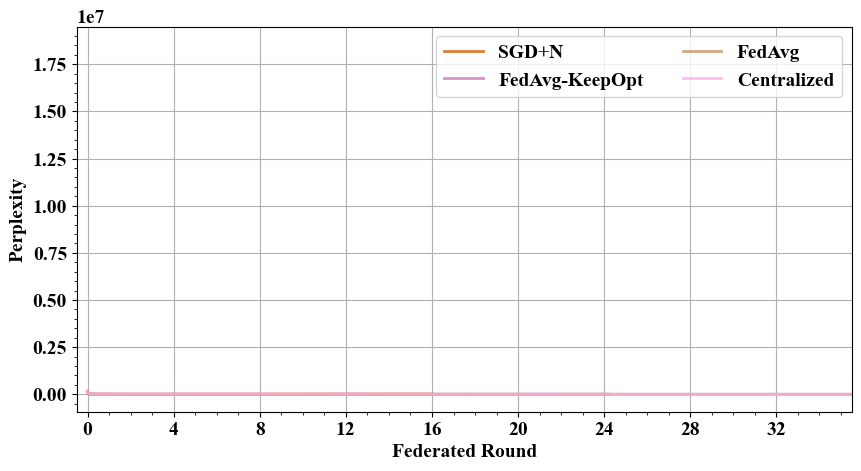

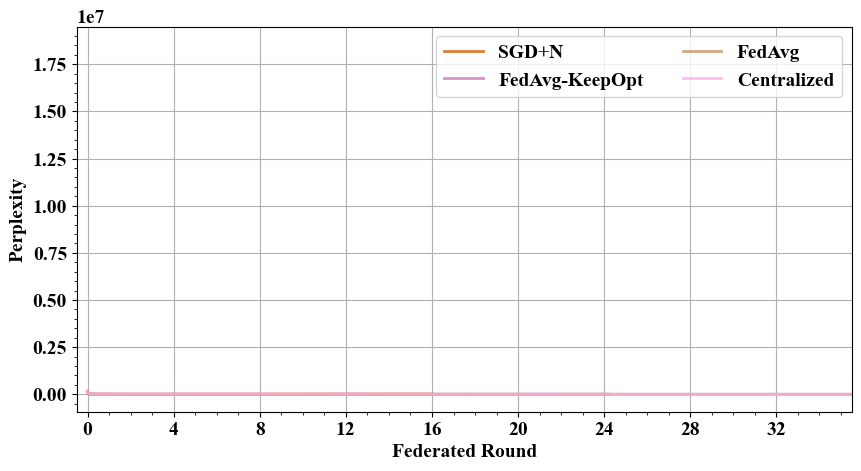

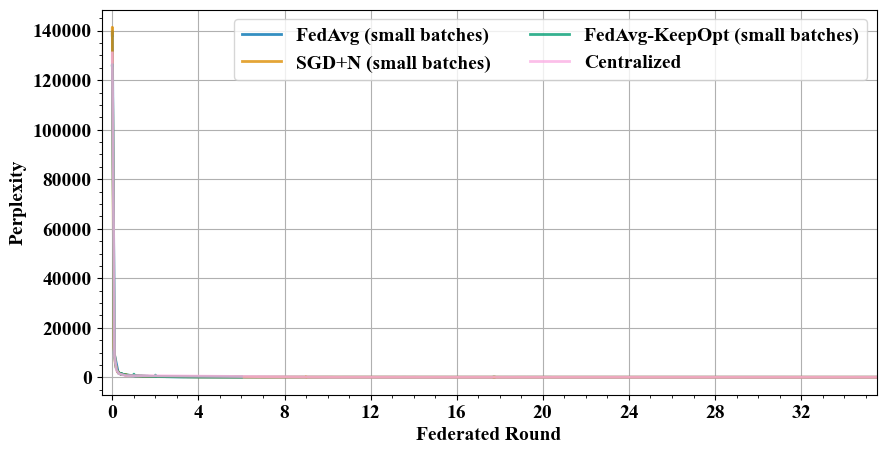

In [76]:
#! All batches
plt.figure(figsize=(10, 5))
for i, new_columns_name in enumerate(rename_columns.values()):
    if "small" in new_columns_name:
        continue
    # tmp_df = df[df[new_columns_name] < 14.0][new_columns_name].dropna()
    tmp_df = df[new_columns_name].dropna()
    sns.lineplot(
        x=df.loc[tmp_df.index, "Step"] / 500,
        y=tmp_df.values,
        label=new_columns_name,
        alpha=0.8,
        color=color_palette[i],
        linestyle=line_styles[0],
        linewidth=2,  # Increase line width
    )
plt.xlim([0.0 - 0.5, 35.0 + 0.5])
# plt.ylim([3.5, 5.0])
# # Reconcile ticks and limits
# _y_ticks = plt.yticks()[0]
# delta = _y_ticks[-1] - _y_ticks[-2]
# plt.ylim(_y_ticks[0], _y_ticks[-1] + (1 / 6) * delta)
# plt.yticks(_y_ticks)

plt.gca().yaxis.set_minor_locator(MultipleLocator(5))

# Force x-ticks to be integers
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(which="major")
plt.minorticks_on()  # Turn on the minor ticks
# Set x and y labels
plt.xlabel(AxisLabels.FED_ROUND.value)
plt.ylabel(AxisLabels.PPL.value)
# Set legend
plt.legend(ncol=2)
plt.savefig("75M_opt_ppl_all.pdf", format="pdf", dpi=800, bbox_inches="tight")
# Show the figure
plt.show()

#! Large batches
plt.figure(figsize=(10, 5))
for i, new_columns_name in enumerate(rename_columns.values()):
    if "small" in new_columns_name:
        continue
    # tmp_df = df[df[new_columns_name] < 14.0][new_columns_name].dropna()
    tmp_df = df[new_columns_name].dropna()
    sns.lineplot(
        x=df.loc[tmp_df.index, "Step"] / 500,
        y=tmp_df.values,
        label=new_columns_name,
        alpha=0.8,
        color=color_palette[i],
        linestyle=line_styles[0],
        linewidth=2,  # Increase line width
    )
plt.xlim([0.0 - 0.5, 35.0 + 0.5])
# plt.ylim([3.5, 5.0])
# # Reconcile ticks and limits
# _y_ticks = plt.yticks()[0]
# delta = _y_ticks[-1] - _y_ticks[-2]
# plt.ylim(_y_ticks[0], _y_ticks[-1] + (1 / 6) * delta)
# plt.yticks(_y_ticks)

plt.gca().yaxis.set_minor_locator(MultipleLocator(5))

# Force x-ticks to be integers
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(which="major")
plt.minorticks_on()  # Turn on the minor ticks
# Set x and y labels
plt.xlabel(AxisLabels.FED_ROUND.value)
plt.ylabel(AxisLabels.PPL.value)
# Set legend
plt.legend(ncol=2)
plt.savefig("75M_opt_ppl.pdf", format="pdf", dpi=800, bbox_inches="tight")
# Show the figure
plt.show()

#! Small batches
plt.figure(figsize=(10, 5))
for i, new_columns_name in enumerate(rename_columns.values()):
    if "small" in new_columns_name or "Centralized" in new_columns_name:
        # tmp_df = df[df[new_columns_name] < 14.0][new_columns_name].dropna()
        tmp_df = df[new_columns_name].dropna()
        sns.lineplot(
            x=df.loc[tmp_df.index, "Step"] / 500,
            y=tmp_df.values,
            label=new_columns_name,
            alpha=0.8,
            color=color_palette[i],
            linestyle=line_styles[0],
            linewidth=2,  # Increase line width
        )
plt.xlim([0.0 - 0.5, 35.0 + 0.5])
# plt.ylim([3.5, 5.0])
# # Reconcile ticks and limits
# _y_ticks = plt.yticks()[0]
# delta = _y_ticks[-1] - _y_ticks[-2]
# plt.ylim(_y_ticks[0], _y_ticks[-1] + (1 / 6) * delta)
# plt.yticks(_y_ticks)

plt.gca().yaxis.set_minor_locator(MultipleLocator(5))

# Force x-ticks to be integers
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(which="major")
plt.minorticks_on()  # Turn on the minor ticks
# Set x and y labels
plt.xlabel(AxisLabels.FED_ROUND.value)
plt.ylabel(AxisLabels.PPL.value)
# Set legend
plt.legend(ncol=2)
plt.savefig("75M_opt_ppl_small_batches.pdf", format="pdf", dpi=800, bbox_inches="tight")
# Show the figure
plt.show()

In [88]:
csv_path = "/Users/lorenzosani/Repositories/flower_llm/notebooks/wandb_export_2024-10-14T16_34_03.366+01_00.csv"

df = pd.read_csv(csv_path)
drop_columns = []
for column in df.columns:
    if "MIN" in column:
        drop_columns.append(column)
    if "MAX" in column:
        drop_columns.append(column)
    if "adam" in column:
        drop_columns.append(column)
    if "yogi" in column:
        drop_columns.append(column)
    if "cons" in column:
        drop_columns.append(column)
rename_columns: dict[str, str] = {}
for column in df.columns:
    if column in drop_columns:
        continue
    if "photon-75M-20240909_161333" in column:
        rename_columns[column] = column.replace(
            "run_uuid: photon-75M-20240909_161333", "FedAvg (small batches)"
        ).replace(" - l2_norm/param/global", "")
    if "diloco-75M-20240905_133735" in column:
        rename_columns[column] = column.replace(
            "run_uuid: diloco-75M-20240905_133735", "SGD+N (small batches)"
        ).replace(" - l2_norm/param/global", "")
    if "photon-75M-keep-opt-20240904_163142" in column:
        rename_columns[column] = column.replace(
            "run_uuid: photon-75M-keep-opt-20240904_163142",
            "FedAvg-KeepOpt (small batches)",
        ).replace(" - l2_norm/param/global", "")
    if "diloco-75M-20240814_090920" in column:
        rename_columns[column] = column.replace(
            "run_uuid: diloco-75M-20240814_090920", "SGD+N"
        ).replace(" - l2_norm/param/global", "")
    if "diloco-75M-fedavg-keep-opt-20240813_091613" in column:
        rename_columns[column] = column.replace(
            "run_uuid: diloco-75M-fedavg-keep-opt-20240813_091613", "FedAvg-KeepOpt"
        ).replace(" - l2_norm/param/global", "")
    if "diloco-75M-fedavg-20240807_134533" in column:
        rename_columns[column] = column.replace(
            "run_uuid: diloco-75M-fedavg-20240807_134533", "FedAvg"
        ).replace(" - l2_norm/param/global", "")
    if "diloco-cen-20240726_121649_centralised" in column:
        rename_columns[column] = column.replace(
            "run_uuid: diloco-cen-20240726_121649_centralised", "Centralized"
        ).replace(" - l2_norm/param/global", "")
df.drop(columns=drop_columns, inplace=True)
df.rename(columns=rename_columns, inplace=True)
df = df.apply(pd.to_numeric, errors="coerce")
df

,Step,FedAvg (small batches),SGD+N (small batches),FedAvg-KeepOpt (small batches),SGD+N,FedAvg-KeepOpt,FedAvg,Centralized
0,10,385.318961,385.334439,385.330778,385.366577,385.272705,385.345218,0
1,20,385.312247,385.327808,385.324598,385.358574,385.264137,385.337453,0
2,30,385.301548,385.317670,385.314848,385.345528,385.250610,385.324813,0
3,40,385.289657,385.306124,385.303567,385.329865,385.234203,385.309383,0
4,50,385.277571,385.294005,385.291959,385.313042,385.216778,385.292745,0
...,...,...,...,...,...,...,...,...
8794,87950,NaN,NaN,NaN,NaN,NaN,NaN,0
8795,87960,NaN,NaN,NaN,NaN,NaN,NaN,0
8796,87970,NaN,NaN,NaN,NaN,NaN,NaN,0
8797,87980,NaN,NaN,NaN,NaN,NaN,NaN,0


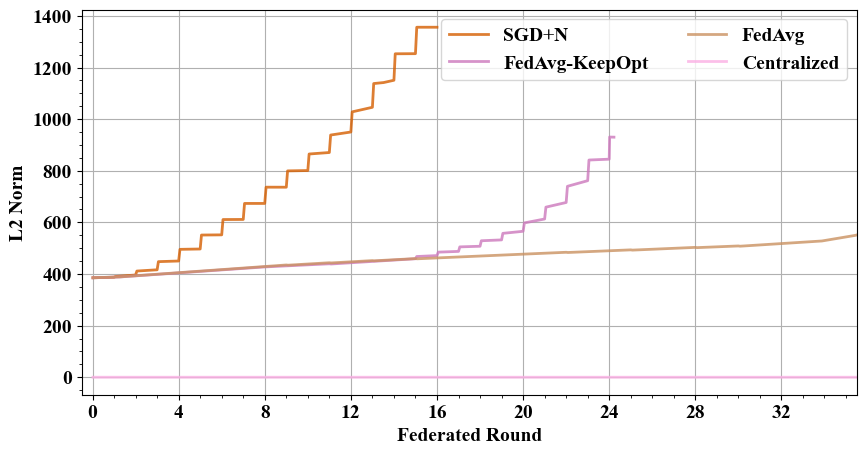

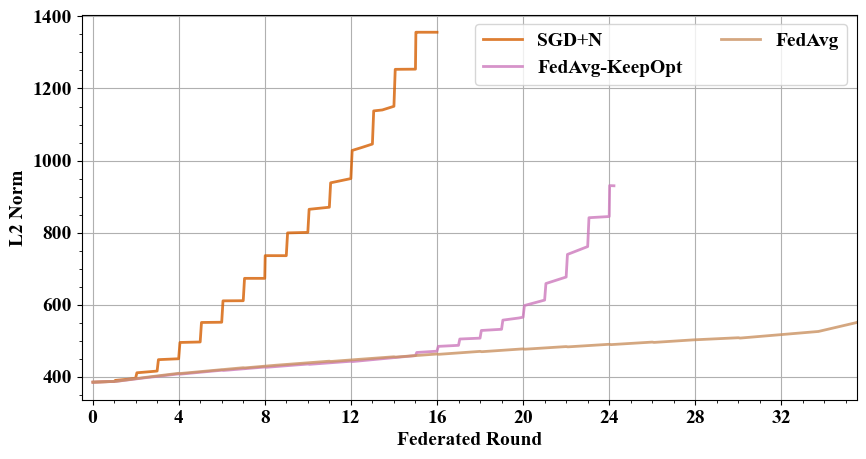

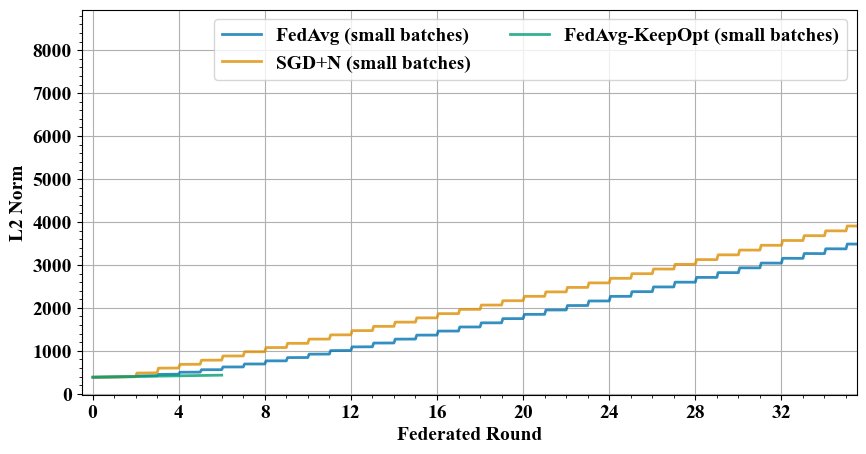

In [89]:
#! All batches
plt.figure(figsize=(10, 5))
for i, new_columns_name in enumerate(rename_columns.values()):
    if "small" in new_columns_name:
        continue
    # tmp_df = df[df[new_columns_name] < 14.0][new_columns_name].dropna()
    tmp_df = df[new_columns_name].dropna()
    sns.lineplot(
        x=df.loc[tmp_df.index, "Step"] / 500,
        y=tmp_df.values,
        label=new_columns_name,
        alpha=0.8,
        color=color_palette[i],
        linestyle=line_styles[0],
        linewidth=2,  # Increase line width
    )
plt.xlim([0.0 - 0.5, 35.0 + 0.5])
# plt.ylim([3.5, 5.0])
# Reconcile ticks and limits
# _y_ticks = plt.yticks()[0]
# delta = _y_ticks[-1] - _y_ticks[-2]
# plt.ylim(_y_ticks[0], _y_ticks[-1] + (1 / 6) * delta)
# plt.yticks(_y_ticks)

plt.gca().yaxis.set_minor_locator(MultipleLocator(5))

# Force x-ticks to be integers
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(which="major")
plt.minorticks_on()  # Turn on the minor ticks
# Set x and y labels
plt.xlabel(AxisLabels.FED_ROUND.value)
plt.ylabel(AxisLabels.L2_NORM.value)
# Set legend
plt.legend(ncol=2)
plt.savefig("75M_opt_l2_norm_all.pdf", format="pdf", dpi=800, bbox_inches="tight")
# Show the figure
plt.show()

#! Large batches
plt.figure(figsize=(10, 5))
for i, new_columns_name in enumerate(rename_columns.values()):
    if "small" in new_columns_name or "Centralized" in new_columns_name:
        continue
    # tmp_df = df[df[new_columns_name] < 14.0][new_columns_name].dropna()
    tmp_df = df[new_columns_name].dropna()
    sns.lineplot(
        x=df.loc[tmp_df.index, "Step"] / 500,
        y=tmp_df.values,
        label=new_columns_name,
        alpha=0.8,
        color=color_palette[i],
        linestyle=line_styles[0],
        linewidth=2,  # Increase line width
    )
plt.xlim([0.0 - 0.5, 35.0 + 0.5])
# plt.ylim([3.5, 5.0])
# Reconcile ticks and limits
# _y_ticks = plt.yticks()[0]
# delta = _y_ticks[-1] - _y_ticks[-2]
# plt.ylim(_y_ticks[0], _y_ticks[-1] + (1 / 6) * delta)
# plt.yticks(_y_ticks)

plt.gca().yaxis.set_minor_locator(MultipleLocator(5))

# Force x-ticks to be integers
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(which="major")
plt.minorticks_on()  # Turn on the minor ticks
# Set x and y labels
plt.xlabel(AxisLabels.FED_ROUND.value)
plt.ylabel(AxisLabels.L2_NORM.value)
# Set legend
plt.legend(ncol=2)
plt.savefig("75M_opt_l2_norm.pdf", format="pdf", dpi=800, bbox_inches="tight")
# Show the figure
plt.show()

#! Small batches
plt.figure(figsize=(10, 5))
for i, new_columns_name in enumerate(rename_columns.values()):
    if "small" in new_columns_name:
        # tmp_df = df[df[new_columns_name] < 14.0][new_columns_name].dropna()
        tmp_df = df[new_columns_name].dropna()
        sns.lineplot(
            x=df.loc[tmp_df.index, "Step"] / 500,
            y=tmp_df.values,
            label=new_columns_name,
            alpha=0.8,
            color=color_palette[i],
            linestyle=line_styles[0],
            linewidth=2,  # Increase line width
        )
plt.xlim([0.0 - 0.5, 35.0 + 0.5])
# plt.ylim([3.5, 5.0])
# Reconcile ticks and limits
# _y_ticks = plt.yticks()[0]
# delta = _y_ticks[-1] - _y_ticks[-2]
# plt.ylim(_y_ticks[0], _y_ticks[-1] + (1 / 6) * delta)
# plt.yticks(_y_ticks)

plt.gca().yaxis.set_minor_locator(MultipleLocator(5))

# Force x-ticks to be integers
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(which="major")
plt.minorticks_on()  # Turn on the minor ticks
# Set x and y labels
plt.xlabel(AxisLabels.FED_ROUND.value)
plt.ylabel(AxisLabels.L2_NORM.value)
# Set legend
plt.legend(ncol=2)
plt.savefig("75M_opt_l2_norm_small_batches.pdf", format="pdf", dpi=800, bbox_inches="tight")
# Show the figure
plt.show()

In [86]:
csv_path = "/Users/lorenzosani/Repositories/flower_llm/notebooks/wandb_export_2024-10-14T16_35_49.981+01_00.csv"

df = pd.read_csv(csv_path)
drop_columns = []
for column in df.columns:
    if "MIN" in column:
        drop_columns.append(column)
    if "MAX" in column:
        drop_columns.append(column)
    if "adam" in column:
        drop_columns.append(column)
    if "yogi" in column:
        drop_columns.append(column)
    if "cons" in column:
        drop_columns.append(column)
rename_columns: dict[str, str] = {}
for column in df.columns:
    if column in drop_columns:
        continue
    if "photon-75M-20240909_161333" in column:
        rename_columns[column] = column.replace(
            "run_uuid: photon-75M-20240909_161333", "FedAvg (small batches)"
        ).replace(" - activations/average/max/full_model_output", "")
    if "diloco-75M-20240905_133735" in column:
        rename_columns[column] = column.replace(
            "run_uuid: diloco-75M-20240905_133735", "SGD+N (small batches)"
        ).replace(" - activations/average/max/full_model_output", "")
    if "photon-75M-keep-opt-20240904_163142" in column:
        rename_columns[column] = column.replace(
            "run_uuid: photon-75M-keep-opt-20240904_163142",
            "FedAvg-KeepOpt (small batches)",
        ).replace(" - activations/average/max/full_model_output", "")
    if "diloco-75M-20240814_090920" in column:
        rename_columns[column] = column.replace(
            "run_uuid: diloco-75M-20240814_090920", "SGD+N"
        ).replace(" - activations/average/max/full_model_output", "")
    if "diloco-75M-fedavg-keep-opt-20240813_091613" in column:
        rename_columns[column] = column.replace(
            "run_uuid: diloco-75M-fedavg-keep-opt-20240813_091613", "FedAvg-KeepOpt"
        ).replace(" - activations/average/max/full_model_output", "")
    if "diloco-75M-fedavg-20240807_134533" in column:
        rename_columns[column] = column.replace(
            "run_uuid: diloco-75M-fedavg-20240807_134533", "FedAvg"
        ).replace(" - activations/average/max/full_model_output", "")
    if "diloco-cen-20240726_121649_centralised" in column:
        rename_columns[column] = column.replace(
            "run_uuid: diloco-cen-20240726_121649_centralised", "Centralized"
        ).replace(" - activations/average/max/full_model_output", "")
df.drop(columns=drop_columns, inplace=True)
df.rename(columns=rename_columns, inplace=True)
df = df.apply(pd.to_numeric, errors="coerce")
df

,Step,FedAvg (small batches),SGD+N (small batches),FedAvg-KeepOpt (small batches),SGD+N,FedAvg-KeepOpt,FedAvg,Centralized
0,0,0.018956,0.040878,0.022964,0.050354,0.038086,0.024017,0.063477
1,10,0.017707,0.036072,0.022659,0.051239,0.038361,0.024628,0.053467
2,20,0.019649,0.042240,0.028748,0.041931,0.031174,0.033997,0.031494
3,30,0.033703,0.041363,0.039330,0.042511,0.041046,0.041016,0.032959
4,40,0.037018,0.037395,0.037346,0.048523,0.053619,0.036438,0.040771
...,...,...,...,...,...,...,...,...
8795,87950,NaN,NaN,NaN,NaN,NaN,NaN,1.968750
8796,87960,NaN,NaN,NaN,NaN,NaN,NaN,1.976562
8797,87970,NaN,NaN,NaN,NaN,NaN,NaN,1.976562
8798,87980,NaN,NaN,NaN,NaN,NaN,NaN,1.968750


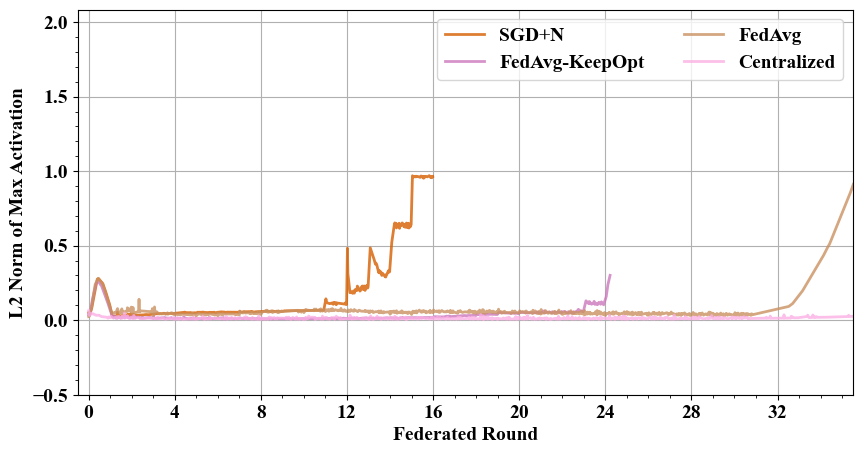

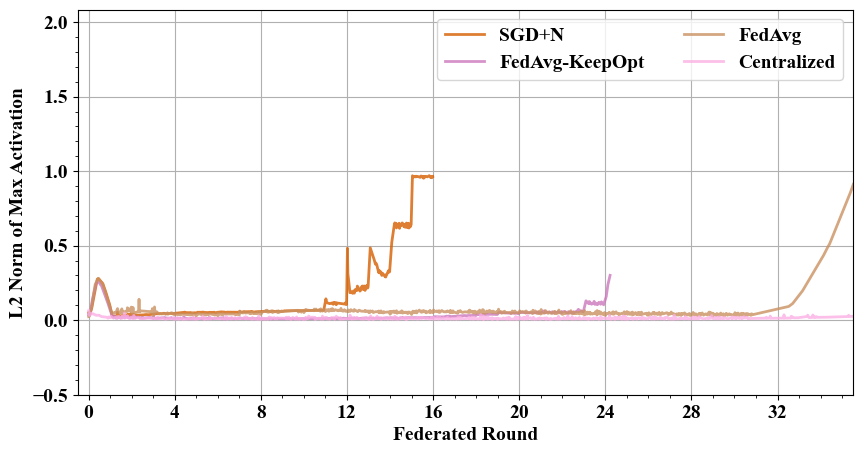

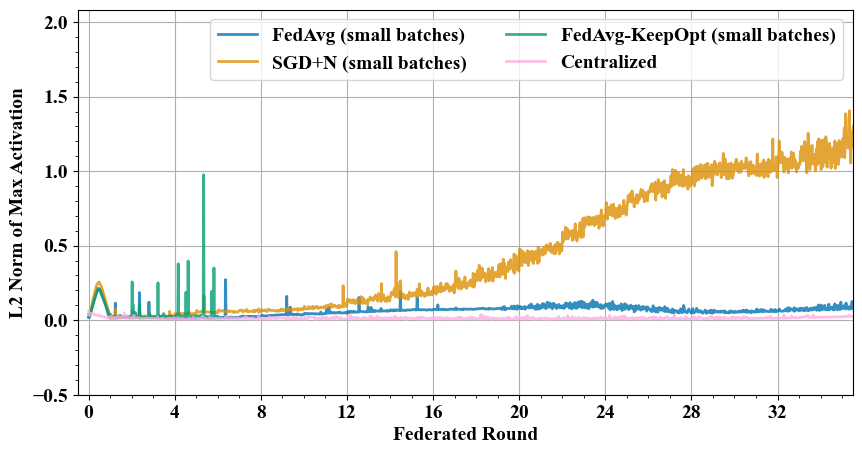

In [87]:
#! All batches
plt.figure(figsize=(10, 5))
for i, new_columns_name in enumerate(rename_columns.values()):
    if "small" in new_columns_name:
        continue
    tmp_df = df[df[new_columns_name] < 14.0][new_columns_name].dropna()
    sns.lineplot(
        x=df.loc[tmp_df.index, "Step"] / 500,
        y=tmp_df.values,
        label=new_columns_name,
        alpha=0.8,
        color=color_palette[i],
        linestyle=line_styles[0],
        linewidth=2,  # Increase line width
    )
plt.xlim([0.0 - 0.5, 35.0 + 0.5])
plt.ylim([0.0 - 0.5, 2.0])
# Reconcile ticks and limits
_y_ticks = plt.yticks()[0]
delta = _y_ticks[-1] - _y_ticks[-2]
plt.ylim(_y_ticks[0], _y_ticks[-1] + (1 / 6) * delta)
plt.yticks(_y_ticks)

plt.gca().yaxis.set_minor_locator(MultipleLocator(5))

# Force x-ticks to be integers
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(which="major")
plt.minorticks_on()  # Turn on the minor ticks
# Set x and y labels
plt.xlabel(AxisLabels.FED_ROUND.value)
plt.ylabel(AxisLabels.ACT_MAX.value)
# Set legend
plt.legend(ncol=2)
plt.savefig("75M_opt_act_all.pdf", format="pdf", dpi=800, bbox_inches="tight")
# Show the figure
plt.show()

#! Large batches
plt.figure(figsize=(10, 5))
for i, new_columns_name in enumerate(rename_columns.values()):
    if "small" in new_columns_name:
        continue
    tmp_df = df[df[new_columns_name] < 14.0][new_columns_name].dropna()
    sns.lineplot(
        x=df.loc[tmp_df.index, "Step"] / 500,
        y=tmp_df.values,
        label=new_columns_name,
        alpha=0.8,
        color=color_palette[i],
        linestyle=line_styles[0],
        linewidth=2,  # Increase line width
    )
plt.xlim([0.0 - 0.5, 35.0 + 0.5])
plt.ylim([0.0 - 0.5, 2.0])
# Reconcile ticks and limits
_y_ticks = plt.yticks()[0]
delta = _y_ticks[-1] - _y_ticks[-2]
plt.ylim(_y_ticks[0], _y_ticks[-1] + (1 / 6) * delta)
plt.yticks(_y_ticks)

plt.gca().yaxis.set_minor_locator(MultipleLocator(5))

# Force x-ticks to be integers
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(which="major")
plt.minorticks_on()  # Turn on the minor ticks
# Set x and y labels
plt.xlabel(AxisLabels.FED_ROUND.value)
plt.ylabel(AxisLabels.ACT_MAX.value)
# Set legend
plt.legend(ncol=2)
plt.savefig("75M_opt_act.pdf", format="pdf", dpi=800, bbox_inches="tight")
# Show the figure
plt.show()

#! Small batches
plt.figure(figsize=(10, 5))
for i, new_columns_name in enumerate(rename_columns.values()):
    if "small" in new_columns_name or "Centralized" in new_columns_name:
        tmp_df = df[df[new_columns_name] < 14.0][new_columns_name].dropna()
        sns.lineplot(
            x=df.loc[tmp_df.index, "Step"] / 500,
            y=tmp_df.values,
            label=new_columns_name,
            alpha=0.8,
            color=color_palette[i],
            linestyle=line_styles[0],
            linewidth=2,  # Increase line width
        )
plt.xlim([0.0 - 0.5, 35.0 + 0.5])
plt.ylim([0.0 - 0.5, 2.0])
# Reconcile ticks and limits
_y_ticks = plt.yticks()[0]
delta = _y_ticks[-1] - _y_ticks[-2]
plt.ylim(_y_ticks[0], _y_ticks[-1] + (1 / 6) * delta)
plt.yticks(_y_ticks)

plt.gca().yaxis.set_minor_locator(MultipleLocator(5))

# Force x-ticks to be integers
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(which="major")
plt.minorticks_on()  # Turn on the minor ticks
# Set x and y labels
plt.xlabel(AxisLabels.FED_ROUND.value)
plt.ylabel(AxisLabels.ACT_MAX.value)
# Set legend
plt.legend(ncol=2)
plt.savefig("75M_opt_act_small_batches.pdf", format="pdf", dpi=800, bbox_inches="tight")
# Show the figure
plt.show()

In [81]:
csv_path = "/Users/lorenzosani/Repositories/flower_llm/notebooks/group1.csv"

df = pd.read_csv(csv_path)
map_run_names = {
    "cen-7B-eval-gauntlet-20240829_122702_centralised": "7B Centralized",
    "cen-760M-eval-gauntlet-20240824_130527_centralised": "760M Centralized",
    "fed-7B-eval-gauntlet-20240823_154456_centralised": "7B Federated",
    "fed-3B-eval-gauntlet-20240823_083221_centralised": "3B Federated",
    "fed-1B-short-eval-gauntlet-20240823_010215_centralised": "1B Federated (short)",
    "fed-1B-long-eval-gauntlet-20240822_234205_centralised": "1B Federated (long)",
    "cen-1B-eval-gauntlet-20240822_193347_centralised": "1B Centralized",
}
df["Name"] = df["Name"].map(map_run_names)
drop_columns = []
for column in df.columns:
    if "arc_challenge/25" in column:
        drop_columns.append(column)
    if "hellaswag/10" in column:
        drop_columns.append(column)
    if "_wandb" in column:
        drop_columns.append(column)
df.drop(columns=drop_columns, inplace=True)
df

,Name,metrics/jeopardy/3-shot/word_origins/InContextLearningLMAccuracy,metrics/jeopardy/3-shot/world_history/InContextLearningLMAccuracy,metrics/arc_challenge/3-shot/InContextLearningMultipleChoiceAccuracy,metrics/bigbench_qa_wikidata/3-shot/InContextLearningLMAccuracy,metrics/hellaswag/0-shot/InContextLearningMultipleChoiceAccuracy,metrics/piqa/0-shot/InContextLearningMultipleChoiceAccuracy,metrics/winogrande/5-shot/InContextLearningMultipleChoiceAccuracy,metrics/arc_easy/3-shot/InContextLearningMultipleChoiceAccuracy,metrics/boolq/0-shot/InContextLearningMultipleChoiceAccuracy,metrics/jeopardy/3-shot/american_history/InContextLearningLMAccuracy,metrics/openbook_qa/10-shot/InContextLearningMultipleChoiceAccuracy,metrics/winograd/3-shot/InContextLearningMultipleChoiceAccuracy,metrics/jeopardy/3-shot/literature/InContextLearningLMAccuracy,metrics/jeopardy/3-shot/science/InContextLearningLMAccuracy,metrics/lambada_openai/0-shot/InContextLearningLMAccuracy
0,7B Centralized,0.00274,0.032172,0.290956,0.510802,0.609241,0.757889,0.544594,0.553030,0.578593,0.021792,0.364,0.747253,0.004082,0.010504,0.524355
1,760M Centralized,0.00000,0.000000,0.253413,0.000000,0.248158,0.485310,0.495659,0.256313,0.576147,0.000000,0.258,0.498168,0.000000,0.000000,0.000000
2,7B Federated,0.00000,0.008043,0.265358,0.447074,0.523999,0.729053,0.522494,0.508417,0.530275,0.000000,0.358,0.681319,0.000000,0.002101,0.457015
3,3B Federated,0.00000,0.000000,0.247440,0.359776,0.455387,0.705114,0.512234,0.460859,0.591132,0.004843,0.316,0.655678,0.000000,0.000000,0.380943
4,1B Federated (short),0.00000,0.000000,0.243174,0.215442,0.349233,0.675735,0.516180,0.389731,0.611621,0.000000,0.274,0.604396,0.000000,0.000000,0.297691
5,1B Federated (long),0.00000,0.000000,0.229522,0.269770,0.391157,0.687160,0.533544,0.406566,0.545260,0.002421,0.290,0.615385,0.000000,0.000000,0.333398
6,1B Centralized,0.00000,0.000000,0.260239,0.000000,0.243477,0.516866,0.528019,0.235269,0.482263,0.000000,0.264,0.516484,0.000000,0.000000,0.000000


In [82]:
sorted(df.columns)

['Name',
 'metrics/arc_challenge/3-shot/InContextLearningMultipleChoiceAccuracy',
 'metrics/arc_easy/3-shot/InContextLearningMultipleChoiceAccuracy',
 'metrics/bigbench_qa_wikidata/3-shot/InContextLearningLMAccuracy',
 'metrics/boolq/0-shot/InContextLearningMultipleChoiceAccuracy',
 'metrics/hellaswag/0-shot/InContextLearningMultipleChoiceAccuracy',
 'metrics/jeopardy/3-shot/american_history/InContextLearningLMAccuracy',
 'metrics/jeopardy/3-shot/literature/InContextLearningLMAccuracy',
 'metrics/jeopardy/3-shot/science/InContextLearningLMAccuracy',
 'metrics/jeopardy/3-shot/word_origins/InContextLearningLMAccuracy',
 'metrics/jeopardy/3-shot/world_history/InContextLearningLMAccuracy',
 'metrics/lambada_openai/0-shot/InContextLearningLMAccuracy',
 'metrics/openbook_qa/10-shot/InContextLearningMultipleChoiceAccuracy',
 'metrics/piqa/0-shot/InContextLearningMultipleChoiceAccuracy',
 'metrics/winograd/3-shot/InContextLearningMultipleChoiceAccuracy',
 'metrics/winogrande/5-shot/InContextLe

In [155]:
jeopardy_columns = []
for column in df.columns:
    if "jeopardy" in column:
        jeopardy_columns.append(column)

In [156]:
replace_column_names = {
    "metrics/arc_challenge/3-shot/InContextLearningMultipleChoiceAccuracy": "ARC-Challenge",
    "metrics/arc_easy/3-shot/InContextLearningMultipleChoiceAccuracy": "ARC-Easy",
    "metrics/bigbench_qa_wikidata/3-shot/InContextLearningLMAccuracy": "BigBench QA Wikidata",
    "metrics/boolq/0-shot/InContextLearningMultipleChoiceAccuracy": "BoolQ",
    "metrics/hellaswag/0-shot/InContextLearningMultipleChoiceAccuracy": "HellaSwag",
    "metrics/jeopardy/3-shot/american_history/InContextLearningLMAccuracy": "Jeopardy American History",
    "metrics/jeopardy/3-shot/literature/InContextLearningLMAccuracy": "Jeopardy Literature",
    "metrics/jeopardy/3-shot/science/InContextLearningLMAccuracy": "Jeopardy Science",
    "metrics/jeopardy/3-shot/word_origins/InContextLearningLMAccuracy": "Jeopardy Word Origins",
    "metrics/jeopardy/3-shot/world_history/InContextLearningLMAccuracy": "Jeopardy World History",
    "metrics/lambada_openai/0-shot/InContextLearningLMAccuracy": "LAMBADA (OpenAI)",
    "metrics/openbook_qa/10-shot/InContextLearningMultipleChoiceAccuracy": "Openbook QA",
    "metrics/piqa/0-shot/InContextLearningMultipleChoiceAccuracy": "PIQA",
    "metrics/winograd/3-shot/InContextLearningMultipleChoiceAccuracy": "Winograd",
    "metrics/winogrande/5-shot/InContextLearningMultipleChoiceAccuracy": "Winogrande",
}
df.rename(columns=replace_column_names, inplace=True)
df

,Name,Jeopardy Word Origins,Jeopardy World History,ARC-Challenge,BigBench QA Wikidata,HellaSwag,PIQA,Winogrande,ARC-Easy,BoolQ,Jeopardy American History,Openbook QA,Winograd,Jeopardy Literature,Jeopardy Science,LAMBADA (OpenAI)
0,7B Centralized,0.00274,0.032172,0.290956,0.510802,0.609241,0.757889,0.544594,0.553030,0.578593,0.021792,0.364,0.747253,0.004082,0.010504,0.524355
1,760M Centralized,0.00000,0.000000,0.253413,0.000000,0.248158,0.485310,0.495659,0.256313,0.576147,0.000000,0.258,0.498168,0.000000,0.000000,0.000000
2,7B Federated,0.00000,0.008043,0.265358,0.447074,0.523999,0.729053,0.522494,0.508417,0.530275,0.000000,0.358,0.681319,0.000000,0.002101,0.457015
3,3B Federated,0.00000,0.000000,0.247440,0.359776,0.455387,0.705114,0.512234,0.460859,0.591132,0.004843,0.316,0.655678,0.000000,0.000000,0.380943
4,1B Federated (short),0.00000,0.000000,0.243174,0.215442,0.349233,0.675735,0.516180,0.389731,0.611621,0.000000,0.274,0.604396,0.000000,0.000000,0.297691
5,1B Federated (long),0.00000,0.000000,0.229522,0.269770,0.391157,0.687160,0.533544,0.406566,0.545260,0.002421,0.290,0.615385,0.000000,0.000000,0.333398
6,1B Centralized,0.00000,0.000000,0.260239,0.000000,0.243477,0.516866,0.528019,0.235269,0.482263,0.000000,0.264,0.516484,0.000000,0.000000,0.000000


In [157]:
jeopardy_columns = []
for column in df.columns:
    if "Jeopardy" in column:
        jeopardy_columns.append(column)
df.drop(columns=jeopardy_columns, inplace=True)

In [158]:
df

,Name,ARC-Challenge,BigBench QA Wikidata,HellaSwag,PIQA,Winogrande,ARC-Easy,BoolQ,Openbook QA,Winograd,LAMBADA (OpenAI)
0,7B Centralized,0.290956,0.510802,0.609241,0.757889,0.544594,0.553030,0.578593,0.364,0.747253,0.524355
1,760M Centralized,0.253413,0.000000,0.248158,0.485310,0.495659,0.256313,0.576147,0.258,0.498168,0.000000
2,7B Federated,0.265358,0.447074,0.523999,0.729053,0.522494,0.508417,0.530275,0.358,0.681319,0.457015
3,3B Federated,0.247440,0.359776,0.455387,0.705114,0.512234,0.460859,0.591132,0.316,0.655678,0.380943
4,1B Federated (short),0.243174,0.215442,0.349233,0.675735,0.516180,0.389731,0.611621,0.274,0.604396,0.297691
5,1B Federated (long),0.229522,0.269770,0.391157,0.687160,0.533544,0.406566,0.545260,0.290,0.615385,0.333398
6,1B Centralized,0.260239,0.000000,0.243477,0.516866,0.528019,0.235269,0.482263,0.264,0.516484,0.000000


In [159]:
csv_path = "/Users/lorenzosani/Repositories/flower_llm/notebooks/group2.csv"

df1 = pd.read_csv(csv_path)
map_run_names = {
    "cen-7B-eval-gauntlet-20240829_122702_centralised": "7B Centralized",
    "cen-760M-eval-gauntlet-20240824_130527_centralised": "760M Centralized",
    "fed-7B-eval-gauntlet-20240823_154456_centralised": "7B Federated",
    "fed-3B-eval-gauntlet-20240823_083221_centralised": "3B Federated",
    "fed-1B-short-eval-gauntlet-20240823_010215_centralised": "1B Federated (short)",
    "fed-1B-long-eval-gauntlet-20240822_234205_centralised": "1B Federated (long)",
    "cen-1B-eval-gauntlet-20240822_193347_centralised": "1B Centralized",
}
df1["Name"] = df1["Name"].map(map_run_names)
drop_columns = []
for column in df1.columns:
    if "_wandb" in column:
        drop_columns.append(column)
    if "arithmetic" in column:
        drop_columns.append(column)
    if "_operator" in column:
        drop_columns.append(column)
    if "gsm8k" in column:
        drop_columns.append(column)
df1.drop(columns=drop_columns, inplace=True)
replace_column_names = {
    "metrics/bigbench_operators/3-shot/InContextLearningLMAccuracy": "Bigbench Operators",
    "metrics/bigbench_strategy_qa/0-shot/InContextLearningMultipleChoiceAccuracy": "Bigbench Strategy QA",
    "metrics/copa/0-shot/InContextLearningMultipleChoiceAccuracy": "COPA",
    "metrics/gsm8k/0-shot/InContextLearningGenerationExactMatchAccuracy": "Gsm8K",
    "metrics/simple_arithmetic_nospaces/5-shot/InContextLearningLMAccuracy": "Arithmetic Nospaces",
    "metrics/simple_arithmetic_withspaces/5-shot/InContextLearningLMAccuracy": "Arithmetic Withspaces",
}
df1.rename(columns=replace_column_names, inplace=True)
df1

,Name,Bigbench Strategy QA,COPA
0,7B Centralized,0.483180,0.68
1,760M Centralized,0.474880,0.58
2,7B Federated,0.466142,0.71
3,3B Federated,0.463958,0.62
4,1B Federated (short),0.470074,0.63
5,1B Federated (long),0.489734,0.63
6,1B Centralized,0.527741,0.46


In [160]:
csv_path = "/Users/lorenzosani/Repositories/flower_llm/notebooks/mmlu.csv"

df2 = pd.read_csv(csv_path)
map_run_names = {
    "cen-7B-eval-gauntlet-20240829_122702_centralised": "7B Centralized",
    "cen-760M-eval-gauntlet-20240824_130527_centralised": "760M Centralized",
    "fed-7B-eval-gauntlet-20240823_154456_centralised": "7B Federated",
    "fed-3B-eval-gauntlet-20240823_083221_centralised": "3B Federated",
    "fed-1B-short-eval-gauntlet-20240823_010215_centralised": "1B Federated (short)",
    "fed-1B-long-eval-gauntlet-20240822_234205_centralised": "1B Federated (long)",
    "cen-1B-eval-gauntlet-20240822_193347_centralised": "1B Centralized",
}
df2["Name"] = df2["Name"].map(map_run_names)
drop_columns = []
for column in df2.columns:
    if "_wandb" in column:
        drop_columns.append(column)
    # if "arithmetic" in column:
    #     drop_columns.append(column)
    # if "_operator" in column:
    #     drop_columns.append(column)
    # if "gsm8k" in column:
    #     drop_columns.append(column)
df2.drop(columns=drop_columns, inplace=True)
# replace_column_names = {
#     "metrics/bigbench_operators/3-shot/InContextLearningLMAccuracy": "Bigbench Operators",
#     "metrics/bigbench_strategy_qa/0-shot/InContextLearningMultipleChoiceAccuracy": "Bigbench Strategy QA",
#     "metrics/copa/0-shot/InContextLearningMultipleChoiceAccuracy": "COPA",
#     "metrics/gsm8k/0-shot/InContextLearningGenerationExactMatchAccuracy": "Gsm8K",
#     "metrics/simple_arithmetic_nospaces/5-shot/InContextLearningLMAccuracy": "Arithmetic Nospaces",
#     "metrics/simple_arithmetic_withspaces/5-shot/InContextLearningLMAccuracy": "Arithmetic Withspaces",
# }
# df2.rename(columns=replace_column_names, inplace=True)
df2

,Name,metrics/mmlu/5-shot/electrical_engineering/InContextLearningMultipleChoiceAccuracy,metrics/mmlu/5-shot/elementary_mathematics/InContextLearningMultipleChoiceAccuracy,metrics/mmlu/5-shot/high_school_psychology/InContextLearningMultipleChoiceAccuracy,metrics/mmlu/5-shot/college_medicine/InContextLearningMultipleChoiceAccuracy,metrics/mmlu/5-shot/computer_security/InContextLearningMultipleChoiceAccuracy,metrics/mmlu/5-shot/college_chemistry/InContextLearningMultipleChoiceAccuracy,metrics/mmlu/5-shot/global_facts/InContextLearningMultipleChoiceAccuracy,metrics/mmlu/5-shot/clinical_knowledge/InContextLearningMultipleChoiceAccuracy,metrics/mmlu/5-shot/business_ethics/InContextLearningMultipleChoiceAccuracy,...,metrics/mmlu/5-shot/high_school_chemistry/InContextLearningMultipleChoiceAccuracy,metrics/mmlu/5-shot/high_school_physics/InContextLearningMultipleChoiceAccuracy,metrics/mmlu/5-shot/human_aging/InContextLearningMultipleChoiceAccuracy,metrics/mmlu/5-shot/jurisprudence/InContextLearningMultipleChoiceAccuracy,metrics/mmlu/5-shot/astronomy/InContextLearningMultipleChoiceAccuracy,metrics/mmlu/5-shot/abstract_algebra/InContextLearningMultipleChoiceAccuracy,metrics/mmlu/5-shot/college_mathematics/InContextLearningMultipleChoiceAccuracy,metrics/mmlu/5-shot/econometrics/InContextLearningMultipleChoiceAccuracy,metrics/mmlu/5-shot/formal_logic/InContextLearningMultipleChoiceAccuracy,metrics/mmlu/5-shot/high_school_us_history/InContextLearningMultipleChoiceAccuracy
0,7B Centralized,0.234483,0.275132,0.234862,0.271676,0.26,0.20,0.30,0.245283,0.23,...,0.246305,0.284768,0.273543,0.231481,0.263158,0.22,0.26,0.263158,0.253968,0.245098
1,760M Centralized,0.296552,0.264550,0.222018,0.265896,0.30,0.18,0.33,0.222642,0.21,...,0.280788,0.264901,0.201794,0.231481,0.296053,0.30,0.26,0.245614,0.150794,0.259804
2,7B Federated,0.248276,0.259259,0.231193,0.190751,0.23,0.27,0.29,0.271698,0.28,...,0.246305,0.264901,0.358744,0.287037,0.282895,0.28,0.18,0.271930,0.214286,0.230392
3,3B Federated,0.248276,0.227513,0.223853,0.254335,0.26,0.30,0.24,0.260377,0.25,...,0.241379,0.284768,0.349776,0.212963,0.263158,0.26,0.18,0.228070,0.277778,0.240196
4,1B Federated (short),0.227586,0.280423,0.238532,0.231214,0.27,0.22,0.20,0.215094,0.28,...,0.256158,0.192053,0.300448,0.250000,0.210526,0.30,0.12,0.192982,0.222222,0.274510
5,1B Federated (long),0.282759,0.259259,0.223853,0.225434,0.29,0.23,0.21,0.230189,0.29,...,0.241379,0.264901,0.282511,0.194444,0.256579,0.28,0.13,0.228070,0.277778,0.250000
6,1B Centralized,0.213793,0.214286,0.247706,0.260116,0.27,0.19,0.26,0.267925,0.21,...,0.275862,0.192053,0.381166,0.194444,0.223684,0.23,0.24,0.271930,0.222222,0.196078


In [161]:
# Aggregate columns containin "mmlu" in the name
mmlu_columns = []
for column in df2.columns:
    if "mmlu" in column:
        mmlu_columns.append(column)
# Aggregate the values of the volumns containing "mmlu" in the name
df2["MMLU"] = df2[mmlu_columns].mean(axis=1)
# Drop the columns containing "mmlu" in the name
df2.drop(columns=mmlu_columns, inplace=True)
df2

,Name,MMLU
0,7B Centralized,0.253713
1,760M Centralized,0.254010
2,7B Federated,0.263118
3,3B Federated,0.251576
4,1B Federated (short),0.248195
5,1B Federated (long),0.246132
6,1B Centralized,0.239394


In [166]:
# Merge df, df1, and df2 by the column "Name"
ddf = pd.merge(df, df1, on="Name")
ddf = pd.merge(ddf, df2, on="Name")
ddf

,Name,ARC-Challenge,BigBench QA Wikidata,HellaSwag,PIQA,Winogrande,ARC-Easy,BoolQ,Openbook QA,Winograd,LAMBADA (OpenAI),Bigbench Strategy QA,COPA,MMLU
0,7B Centralized,0.290956,0.510802,0.609241,0.757889,0.544594,0.553030,0.578593,0.364,0.747253,0.524355,0.483180,0.68,0.253713
1,760M Centralized,0.253413,0.000000,0.248158,0.485310,0.495659,0.256313,0.576147,0.258,0.498168,0.000000,0.474880,0.58,0.254010
2,7B Federated,0.265358,0.447074,0.523999,0.729053,0.522494,0.508417,0.530275,0.358,0.681319,0.457015,0.466142,0.71,0.263118
3,3B Federated,0.247440,0.359776,0.455387,0.705114,0.512234,0.460859,0.591132,0.316,0.655678,0.380943,0.463958,0.62,0.251576
4,1B Federated (short),0.243174,0.215442,0.349233,0.675735,0.516180,0.389731,0.611621,0.274,0.604396,0.297691,0.470074,0.63,0.248195
5,1B Federated (long),0.229522,0.269770,0.391157,0.687160,0.533544,0.406566,0.545260,0.290,0.615385,0.333398,0.489734,0.63,0.246132
6,1B Centralized,0.260239,0.000000,0.243477,0.516866,0.528019,0.235269,0.482263,0.264,0.516484,0.000000,0.527741,0.46,0.239394


In [167]:
ddf.to_csv("merged.csv", index=False)


In [165]:
ddf = pd.merge([df, df1, df2])
ddf

TypeError: merge() missing 1 required positional argument: 'right'